# Extract polygon pixel spectra for radiometry evaluation

This notebook extracts all valid 11-band pixel spectra inside the spectrally
constant-feature polygons at Westham and Brunswick for the May 4 and May 18,
2026 flights.

It provides:

- DLS and NoDLS feature spectra;
- May 4 and May 18 comparisons;
- pixel-level and polygon-band summary outputs;
- DLS versus NoDLS agreement diagnostics;
- temporal gain and offset correction factors;
- feature-cluster bootstrap uncertainty for the fitted coefficients.

## Important assumptions

1. Files named `10Band` contain 11 source bands.
2. Source band 5 is PAN:
   `B1, B2, B3, B4, PAN, B5, B6, B7, B8, B9, B10`.
3. PAN is retained in tables and temporal per-band fits, but excluded from
   wavelength-based spectra and the pooled 10-band fit.
4. Non-default dataset scale and offset metadata are applied when present.
5. The extraction uses the reported raster CRS when
   `ASSUMED_RASTER_CRS = None`.

> No SAS URL or token is stored in this notebook.

## 1. Imports and plotting setup

In [2]:
from pathlib import Path
import json
import os
import re
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns

from IPython.display import display
from rasterio.features import geometry_mask, geometry_window
from rasterio.transform import xy
from shapely.geometry import mapping
from sklearn.metrics import r2_score

plt.style.use("default")
%config InlineBackend.figure_format = "retina"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## 2. Project and Azure/container configuration

In [3]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
print("Project root:", PROJECT_ROOT)

STORAGE_ACCOUNT_NAME = "geoanalytics"
CONTAINER_NAME = "wesa-fup-restricted-027817p"
USE_AZURE_CONTAINER = True

if USE_AZURE_CONTAINER:
    try:
        import hatfield_funcs as hf

        if os.getenv("GA_STORAGE_ACCOUNT_NAME") is None:
            warnings.warn(
                "GA_STORAGE_ACCOUNT_NAME is not set. "
                "GeoAnalytics managed-identity access may not be configured."
            )

        hf.config.configure_azure()
        hf.config.configure_data_root_path(CONTAINER_NAME)

        os.environ.setdefault("AZURE_STORAGE_ACCOUNT", STORAGE_ACCOUNT_NAME)
        os.environ.setdefault("GDAL_AZURE_USE_MSI", "YES")
        os.environ.setdefault("GDAL_CACHEMAX", "512")

        sas_token = os.getenv("AZURE_STORAGE_SAS_TOKEN")
        if sas_token:
            os.environ["AZURE_STORAGE_SAS_TOKEN"] = sas_token
    except ImportError:
        warnings.warn(
            "hatfield_funcs is unavailable. Azure authentication must "
            "already be configured."
        )


def container_path(path, container_name=CONTAINER_NAME):
    normalized = str(path).replace("\\", "/").lstrip("/")
    if USE_AZURE_CONTAINER:
        return f"/vsiaz/{container_name}/{normalized}"
    return str(PROJECT_ROOT / normalized)

Project root: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm


## 3. Analysis parameters and band definitions

In [4]:
ALL_TOUCHED = False
ASSUMED_RASTER_CRS = None
REQUIRE_ALL_BANDS_VALID = True
APPLY_NONDEFAULT_SCALE_OFFSET = True

SAVE_OUTPUTS = True
OVERWRITE_OUTPUTS = True

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imagery"
    / "radiometry_eval"
    / "polygon_pixel_spectra"
)

SOURCE_BAND_NUMBERS = list(range(1, 12))
SOURCE_BAND_NAMES = [
    "B1", "B2", "B3", "B4", "PAN",
    "B5", "B6", "B7", "B8", "B9", "B10",
]

SPECTRAL_WAVELENGTHS_NM = {
    "B1": 444,
    "B2": 475,
    "B3": 531,
    "B4": 560,
    "B5": 650,
    "B6": 668,
    "B7": 705,
    "B8": 717,
    "B9": 740,
    "B10": 842,
}

BAND_METADATA = pd.DataFrame({
    "source_band": SOURCE_BAND_NUMBERS,
    "band_name": SOURCE_BAND_NAMES,
})
BAND_METADATA["wavelength_nm"] = BAND_METADATA["band_name"].map(
    SPECTRAL_WAVELENGTHS_NM
)
BAND_METADATA["is_pan"] = BAND_METADATA["band_name"].eq("PAN")

display(BAND_METADATA)

,source_band,band_name,wavelength_nm,is_pan
0,1,B1,444.0,False
1,2,B2,475.0,False
2,3,B3,531.0,False
3,4,B4,560.0,False
4,5,PAN,NaN,True
5,6,B5,650.0,False
6,7,B6,668.0,False
7,8,B7,705.0,False
8,9,B8,717.0,False
9,10,B9,740.0,False


## 4. Input paths

In [5]:
POLYGON_RELATIVE_PATHS = {
    "westham": Path(
        "data/processed/imagery/radiometry_eval/"
        "spectrally_constant_features_westham_v2.geojson"
    ),
    "brunswick": Path(
        "data/processed/imagery/radiometry_eval/"
        "spectrally_constant_features_brunswick_v2.geojson"
    ),
}

RASTER_RELATIVE_PATHS = {
    ("2026-05-04", "brunswick", "DLS"): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Brunswick_20260504_DLS_v2.tif"
    ),
    ("2026-05-04", "brunswick", "NoDLS"): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Brunswick_20260504_NoDLS_v2.tif"
    ),
    ("2026-05-04", "westham", "DLS"): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Westham_20260504_DLS_v2.tif"
    ),
    ("2026-05-04", "westham", "NoDLS"): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Westham_20260504_NoDLS_v2.tif"
    ),
    ("2026-05-18", "brunswick", "DLS"): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Brunswick_20260518_DLS_v2.tif"
    ),
    ("2026-05-18", "brunswick", "NoDLS"): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Brunswick_20260518_NoDLS_v2.tif"
    ),
    ("2026-05-18", "westham", "DLS"): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Westham_20260518_DLS_v2.tif"
    ),
    ("2026-05-18", "westham", "NoDLS"): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Westham_20260518_NoDLS_v2.tif"
    ),
}

POLYGON_PATHS = {
    site: container_path(path)
    for site, path in POLYGON_RELATIVE_PATHS.items()
}
RASTER_PATHS = {
    key: container_path(path)
    for key, path in RASTER_RELATIVE_PATHS.items()
}

input_registry = pd.DataFrame([
    {
        "flight_date": flight_date,
        "site": site,
        "dls_mode": dls_mode,
        "raster_path": path,
        "polygon_path": POLYGON_PATHS[site],
    }
    for (flight_date, site, dls_mode), path in RASTER_PATHS.items()
]).sort_values(["flight_date", "site", "dls_mode"])

display(input_registry)

,flight_date,site,dls_mode,raster_path,polygon_path
0,2026-05-04,brunswick,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...,/vsiaz/wesa-fup-restricted-027817p/data/proces...
1,2026-05-04,brunswick,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...,/vsiaz/wesa-fup-restricted-027817p/data/proces...
2,2026-05-04,westham,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...,/vsiaz/wesa-fup-restricted-027817p/data/proces...
3,2026-05-04,westham,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...,/vsiaz/wesa-fup-restricted-027817p/data/proces...
4,2026-05-18,brunswick,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...,/vsiaz/wesa-fup-restricted-027817p/data/proces...
5,2026-05-18,brunswick,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...,/vsiaz/wesa-fup-restricted-027817p/data/proces...
6,2026-05-18,westham,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...,/vsiaz/wesa-fup-restricted-027817p/data/proces...
7,2026-05-18,westham,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...,/vsiaz/wesa-fup-restricted-027817p/data/proces...


## 5. Inspect rasters and polygon files

In [6]:
def inspect_raster(path, test_window_size=16):
    with rasterio.open(path) as src:
        width = min(test_window_size, src.width)
        height = min(test_window_size, src.height)
        test = src.read(
            1,
            window=rasterio.windows.Window(0, 0, width, height),
            masked=True,
        )
        return {
            "path": path,
            "driver": src.driver,
            "width": src.width,
            "height": src.height,
            "count": src.count,
            "dtypes": src.dtypes,
            "nodata": src.nodata,
            "reported_crs": str(src.crs),
            "assumed_extraction_crs": ASSUMED_RASTER_CRS,
            "transform": src.transform,
            "bounds": tuple(src.bounds),
            "descriptions": list(src.descriptions),
            "scales": list(src.scales),
            "offsets": list(src.offsets),
            "test_read_shape": test.shape,
            "test_read_successful": True,
        }


records = []
for (flight_date, site, dls_mode), path in RASTER_PATHS.items():
    record = inspect_raster(path)
    record.update({
        "flight_date": flight_date,
        "site": site,
        "dls_mode": dls_mode,
    })
    records.append(record)

raster_info = (
    pd.DataFrame(records)
    .set_index(["flight_date", "site", "dls_mode"])
    .sort_index()
)
display(raster_info.T)

if not raster_info["count"].eq(11).all():
    raise ValueError(
        "Every configured raster must contain 11 bands. "
        f"Observed: {sorted(raster_info['count'].unique())}"
    )

flight_date                                                    2026-05-04  \
site                                                            brunswick   
dls_mode                                                              DLS   
path                    /vsiaz/wesa-fup-restricted-027817p/airborne_da...   
driver                                                              GTiff   
width                                                               22597   
height                                                              16490   
count                                                                  11   
dtypes                  (float32, float32, float32, float32, float32, ...   
nodata                                                           -32767.0   
reported_crs                                                    EPSG:3157   
assumed_extraction_crs                                               None   
transform               (0.299999999999999, 0.0, 484938.6305083032, 0....   
bounds                  (484938.6305083032, 5431108.011023744, 491717....   
descriptions            [None, None, None, None, None, None, None, Non...   
scales                  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...   
offsets                 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
test_read_shape                                                  (16, 16)   
test_read_successful                                                 True   

flight_date                                                                \
site                                                                        
dls_mode                                                            NoDLS   
path                    /vsiaz/wesa-fup-restricted-027817p/airborne_da...   
driver                                                              GTiff   
width                                                               22593   
height                                                              16498   
count                                                                  11   
dtypes                  (float32, float32, float32, float32, float32, ...   
nodata                                                           -32767.0   
reported_crs                                                    EPSG:3157   
assumed_extraction_crs                                               None   
transform               (0.30000000000000104, 0.0, 484939.80129396444,...   
bounds                  (484939.80129396444, 5431107.932238819, 491717...   
descriptions            [None, None, None, None, None, None, None, Non...   
scales                  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...   
offsets                 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
test_read_shape                                                  (16, 16)   
test_read_successful                                                 True   

flight_date                                                                \
site                                                              westham   
dls_mode                                                              DLS   
path                    /vsiaz/wesa-fup-restricted-027817p/airborne_da...   
driver                                                              GTiff   
width                                                               16588   
height                                                              20093   
count                                                                  11   
dtypes                  (float32, float32, float32, float32, float32, ...   
nodata                                                           -32767.0   
reported_crs            COMPD_CS["NAD83(CSRS) / UTM zone 10N + unknown...   
assumed_extraction_crs                                               None   
transform               (0.2999924922001158, 0.0, 482555.84880407527, ...   
bounds                  (482555.84880407527, 5434856.730912491, 487532.

In [7]:
def choose_feature_id_field(gdf):
    candidates = [
        "feature_id", "id", "ID", "name", "Name",
        "label", "Label", "description", "Description",
        "Descrip", "class", "Class",
    ]
    for candidate in candidates:
        if candidate in gdf.columns:
            return candidate
    return None


polygon_layers = {}

for site, path in POLYGON_PATHS.items():
    gdf = gpd.read_file(path)

    if gdf.crs is None:
        raise ValueError(f"{site} polygons have no CRS: {path}")
    if gdf.geometry.isna().any():
        raise ValueError(f"{site} polygons contain missing geometries.")
    if (~gdf.geometry.is_valid).any():
        warnings.warn(f"{site}: repairing invalid geometries with buffer(0).")
        gdf["geometry"] = gdf.geometry.buffer(0)

    id_field = choose_feature_id_field(gdf)
    gdf = (
        gdf.reset_index(drop=False)
        .rename(columns={"index": "source_feature_index"})
    )

    if id_field is None:
        gdf["feature_id"] = [
            f"{site}_{index:03d}"
            for index in range(1, len(gdf) + 1)
        ]
    else:
        gdf["feature_id"] = (
            gdf[id_field].astype("string").fillna("").str.strip()
        )
        missing_id = gdf["feature_id"].eq("")
        gdf.loc[missing_id, "feature_id"] = [
            f"{site}_{index:03d}"
            for index in gdf.loc[
                missing_id, "source_feature_index"
            ]
        ]

    if "description" not in gdf.columns:
        gdf["description"] = gdf["feature_id"]

    gdf["site"] = site
    polygon_layers[site] = gdf

    print(
        f"{site}: {len(gdf)} polygons; CRS={gdf.crs}; "
        f"feature ID source={id_field or 'generated'}"
    )
    display(gdf.drop(columns="geometry").head())

westham: 10 polygons; CRS=EPSG:3157; feature ID source=id


/home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/.venv/lib/python3.10/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


,source_feature_index,id,description,day,feature_id,site
0,0,1,grey panel,4.0,1,westham
1,1,1,grey panel,18.0,1,westham
2,2,2,black panel,18.0,2,westham
3,3,3,grey roof,NaN,3,westham
4,4,4,grey roof,NaN,4,westham


brunswick: 16 polygons; CRS=EPSG:3157; feature ID source=id


/home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/.venv/lib/python3.10/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


,source_feature_index,fid,id,description,day,feature_id,site
0,0,1,1,Brown thing on construction site,18.0,1,brunswick
1,1,2,1,Brown thing on construction site,4.0,1,brunswick
2,2,3,2,Road dark,NaN,2,brunswick
3,3,4,3,Road bright,NaN,3,brunswick
4,4,5,4,Grey roof,NaN,4,brunswick


## 6. Extraction functions

The pixel table is wide: one row per valid pixel and one column per source band.
The polygon summary is long: one row per image × feature × band.

In [8]:
def extraction_crs(src):
    if ASSUMED_RASTER_CRS is not None:
        return ASSUMED_RASTER_CRS
    if src.crs is None:
        raise ValueError(
            "Raster has no CRS and ASSUMED_RASTER_CRS is None."
        )
    return src.crs


def nondefault_scale_offset(src):
    scales = np.asarray(src.scales, dtype=float)
    offsets = np.asarray(src.offsets, dtype=float)
    nondefault = (
        not np.allclose(scales, 1.0)
        or not np.allclose(offsets, 0.0)
    )
    return scales, offsets, nondefault


def extract_polygon_pixels(
    raster_path,
    polygon_gdf,
    *,
    flight_date,
    site,
    dls_mode,
    all_touched=ALL_TOUCHED,
    require_all_bands_valid=REQUIRE_ALL_BANDS_VALID,
):
    pixel_frames = []
    feature_records = []

    with rasterio.open(raster_path) as src:
        if src.count != 11:
            raise ValueError(
                f"Expected 11 bands but found {src.count}: {raster_path}"
            )

        polygons = polygon_gdf.to_crs(extraction_crs(src)).copy()

        scales, offsets, nondefault = nondefault_scale_offset(src)
        apply_scale_offset = (
            APPLY_NONDEFAULT_SCALE_OFFSET and nondefault
        )

        flight_day = int(flight_date.split("-")[-1])

        for _, feature in polygons.iterrows():
            feature_id = str(feature["feature_id"])

            feature_day = None
            if "day" in feature.index and pd.notna(feature["day"]):
                feature_day = int(feature["day"])

            if feature_day is not None and feature_day != flight_day:
                continue

            geom = feature.geometry

            try:
                window = geometry_window(
                    src,
                    [mapping(geom)],
                    pad_x=0,
                    pad_y=0,
                    boundless=False,
                )
            except rasterio.errors.WindowError:
                feature_records.append({
                    "flight_date": flight_date,
                    "site": site,
                    "dls_mode": dls_mode,
                    "feature_id": feature_id,
                    "pixel_count": 0,
                    "status": "no_overlap",
                })
                continue

            data = src.read(
                indexes=SOURCE_BAND_NUMBERS,
                window=window,
                masked=True,
            )
            transform = src.window_transform(window)

            inside = geometry_mask(
                [mapping(geom)],
                out_shape=(int(window.height), int(window.width)),
                transform=transform,
                invert=True,
                all_touched=all_touched,
            )

            values = np.ma.getdata(data).astype("float64", copy=False)
            band_mask = np.ma.getmaskarray(data)

            if apply_scale_offset:
                values = (
                    values * scales[:, None, None]
                    + offsets[:, None, None]
                )

            finite = np.isfinite(values)

            if require_all_bands_valid:
                valid = (
                    inside
                    & (~band_mask).all(axis=0)
                    & finite.all(axis=0)
                )
            else:
                valid = inside & ((~band_mask) & finite).any(axis=0)

            local_rows, local_cols = np.where(valid)
            pixel_count = len(local_rows)

            if pixel_count == 0:
                feature_records.append({
                    "flight_date": flight_date,
                    "site": site,
                    "dls_mode": dls_mode,
                    "feature_id": feature_id,
                    "pixel_count": 0,
                    "status": "no_valid_pixels",
                })
                continue

            global_rows = local_rows + int(window.row_off)
            global_cols = local_cols + int(window.col_off)
            xs, ys = xy(
                src.transform,
                global_rows,
                global_cols,
                offset="center",
            )

            pixel_values = values[:, local_rows, local_cols].T
            pixel_df = pd.DataFrame(
                pixel_values,
                columns=SOURCE_BAND_NAMES,
            )

            metadata = [
                ("flight_date", flight_date),
                ("site", site),
                ("dls_mode", dls_mode),
                ("feature_id", feature_id),
                ("pixel_id", np.arange(pixel_count)),
                ("raster_row", global_rows),
                ("raster_col", global_cols),
                ("x", np.asarray(xs)),
                ("y", np.asarray(ys)),
            ]
            for position, (column, value) in enumerate(metadata):
                pixel_df.insert(position, column, value)

            pixel_df["raster_path"] = raster_path
            pixel_df["scale_offset_applied"] = apply_scale_offset
            pixel_frames.append(pixel_df)

            feature_records.append({
                "flight_date": flight_date,
                "site": site,
                "dls_mode": dls_mode,
                "feature_id": feature_id,
                "pixel_count": pixel_count,
                "status": "ok",
                "scale_offset_applied": apply_scale_offset,
            })

    pixels = (
        pd.concat(pixel_frames, ignore_index=True)
        if pixel_frames else pd.DataFrame()
    )
    return pixels, pd.DataFrame(feature_records)


def summarize_pixel_spectra(pixel_df):
    if pixel_df.empty:
        return pd.DataFrame()

    id_columns = [
        "flight_date", "site", "dls_mode", "feature_id",
    ]

    long_pixels = pixel_df.melt(
        id_vars=id_columns + [
            "pixel_id", "raster_row", "raster_col", "x", "y",
        ],
        value_vars=SOURCE_BAND_NAMES,
        var_name="band_name",
        value_name="value",
    )

    summary = (
        long_pixels
        .groupby(
            id_columns + ["band_name"],
            observed=True,
        )["value"]
        .agg(
            pixel_count="count",
            mean="mean",
            median="median",
            std="std",
            minimum="min",
            maximum="max",
            q05=lambda x: x.quantile(0.05),
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            q95=lambda x: x.quantile(0.95),
        )
        .reset_index()
    )

    summary["cv_percent"] = np.where(
        summary["mean"].abs() > 0,
        100 * summary["std"] / summary["mean"].abs(),
        np.nan,
    )

    return summary.merge(
        BAND_METADATA,
        on="band_name",
        how="left",
        validate="many_to_one",
    )

## 7. Run extraction and save per-image outputs

In [9]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_pixel_tables = []
all_summaries = []
all_logs = []

for (flight_date, site, dls_mode), raster_path in sorted(
    RASTER_PATHS.items()
):
    print(f"Extracting: {flight_date} | {site} | {dls_mode}")

    pixels, log = extract_polygon_pixels(
        raster_path,
        polygon_layers[site],
        flight_date=flight_date,
        site=site,
        dls_mode=dls_mode,
    )
    summary = summarize_pixel_spectra(pixels)

    all_pixel_tables.append(pixels)
    all_summaries.append(summary)
    all_logs.append(log)

    print(
        f"  pixels={len(pixels):,}; "
        f"features={(log['status'] == 'ok').sum() if not log.empty else 0}"
    )

    if SAVE_OUTPUTS:
        stem = f"{flight_date}_{site}_{dls_mode}".replace("-", "")
        pixels.to_parquet(
            OUTPUT_DIR / f"{stem}_pixel_spectra.parquet",
            index=False,
        )
        summary.to_parquet(
            OUTPUT_DIR / f"{stem}_polygon_band_summary.parquet",
            index=False,
        )
        log.to_csv(
            OUTPUT_DIR / f"{stem}_extraction_log.csv",
            index=False,
        )

pixel_spectra = pd.concat(all_pixel_tables, ignore_index=True)
polygon_band_summary = pd.concat(all_summaries, ignore_index=True)
extraction_log = pd.concat(all_logs, ignore_index=True)

if SAVE_OUTPUTS:
    polygon_band_summary.to_parquet(
        OUTPUT_DIR / "all_polygon_band_summaries.parquet",
        index=False,
    )
    extraction_log.to_csv(
        OUTPUT_DIR / "all_extraction_logs.csv",
        index=False,
    )

display(extraction_log)
display(polygon_band_summary.head())
print("Total pixel spectra:", f"{len(pixel_spectra):,}")

Extracting: 2026-05-04 | brunswick | DLS
  pixels=2,002; features=13
Extracting: 2026-05-04 | brunswick | NoDLS
  pixels=1,993; features=13
Extracting: 2026-05-04 | westham | DLS
  pixels=490; features=8
Extracting: 2026-05-04 | westham | NoDLS
  pixels=489; features=8
Extracting: 2026-05-18 | brunswick | DLS
  pixels=2,038; features=13
Extracting: 2026-05-18 | brunswick | NoDLS
  pixels=2,035; features=13
Extracting: 2026-05-18 | westham | DLS
  pixels=495; features=9
Extracting: 2026-05-18 | westham | NoDLS
  pixels=511; features=9


,flight_date,site,dls_mode,feature_id,pixel_count,status,scale_offset_applied
0,2026-05-04,brunswick,DLS,1,36,ok,False
1,2026-05-04,brunswick,DLS,2,102,ok,False
2,2026-05-04,brunswick,DLS,3,124,ok,False
3,2026-05-04,brunswick,DLS,4,36,ok,False
4,2026-05-04,brunswick,DLS,5,45,ok,False
5,2026-05-04,brunswick,DLS,6,297,ok,False
6,2026-05-04,brunswick,DLS,7,272,ok,False
7,2026-05-04,brunswick,DLS,8,374,ok,False
8,2026-05-04,brunswick,DLS,9,102,ok,False
9,2026-05-04,brunswick,DLS,10,21,ok,False


,flight_date,site,dls_mode,feature_id,band_name,pixel_count,mean,median,std,minimum,maximum,q05,q25,q75,q95,cv_percent,source_band,wavelength_nm,is_pan
0,2026-05-04,brunswick,DLS,1,B1,36,0.020121,0.019717,0.001642,0.017811,0.023529,0.017950,0.019069,0.020943,0.023307,8.161209,1,444.0,False
1,2026-05-04,brunswick,DLS,1,B10,36,0.027272,0.027000,0.001654,0.024925,0.030613,0.025163,0.026125,0.028252,0.030268,6.063728,11,842.0,False
2,2026-05-04,brunswick,DLS,1,B2,36,0.018316,0.017833,0.001722,0.015915,0.021922,0.015943,0.017149,0.019645,0.021507,9.402281,2,475.0,False
3,2026-05-04,brunswick,DLS,1,B3,36,0.019767,0.019613,0.001342,0.017643,0.022578,0.018039,0.018880,0.020673,0.022300,6.788893,3,531.0,False
4,2026-05-04,brunswick,DLS,1,B4,36,0.020891,0.020692,0.001245,0.019167,0.023875,0.019473,0.019955,0.021433,0.023297,5.960338,4,560.0,False


Total pixel spectra: 10,053


## 8. Extraction quality-control tables

In [10]:
qc_by_image = (
    extraction_log
    .groupby(
        ["flight_date", "site", "dls_mode", "status"],
        observed=True,
    )
    .agg(
        feature_count=("feature_id", "nunique"),
        pixel_count=("pixel_count", "sum"),
    )
    .reset_index()
)
display(qc_by_image)

pixel_count_qc = (
    extraction_log.loc[extraction_log["status"].eq("ok")]
    .pivot_table(
        index=["site", "feature_id"],
        columns=["flight_date", "dls_mode"],
        values="pixel_count",
        aggfunc="first",
    )
)
display(pixel_count_qc)

,flight_date,site,dls_mode,status,feature_count,pixel_count
0,2026-05-04,brunswick,DLS,ok,13,2002
1,2026-05-04,brunswick,NoDLS,ok,13,1993
2,2026-05-04,westham,DLS,ok,8,490
3,2026-05-04,westham,NoDLS,ok,8,489
4,2026-05-18,brunswick,DLS,ok,13,2038
5,2026-05-18,brunswick,NoDLS,ok,13,2035
6,2026-05-18,westham,DLS,ok,9,495
7,2026-05-18,westham,NoDLS,ok,9,511


flight_date          2026-05-04        2026-05-18       
dls_mode                    DLS  NoDLS        DLS  NoDLS
site      feature_id                                    
brunswick 1                36.0   36.0       57.0   57.0
          10               21.0   20.0       21.0   21.0
          11              139.0  137.0      137.0  136.0
          12               29.0   28.0       29.0   28.0
          13              425.0  423.0      428.0  427.0
          2               102.0  103.0      101.0  101.0
          3               124.0  121.0      123.0  123.0
          4                36.0   33.0       37.0   37.0
          5                45.0   45.0       42.0   42.0
          6               297.0  301.0      298.0  298.0
          7               272.0  272.0      269.0  270.0
          8               374.0  376.0      376.0  375.0
          9               102.0   98.0      120.0  120.0
westham   1                24.0   30.0       20.0   29.0
          2                 NaN    NaN       16.0   16.0
          3                48.0   43.0       43.0   48.0
          4                40.0   38.0       38.0   40.0
          5                72.0   72.0       72.0   72.0
          6                84.0   85.0       85.0   84.0
          7               160.0  159.0      159.0  160.0
          8                19.0   18.0       18.0   19.0
          9                43.0   44.0       44.0   43.0

## 9. Plot each feature's mean ± standard-deviation spectrum: DLS versus NoDLS

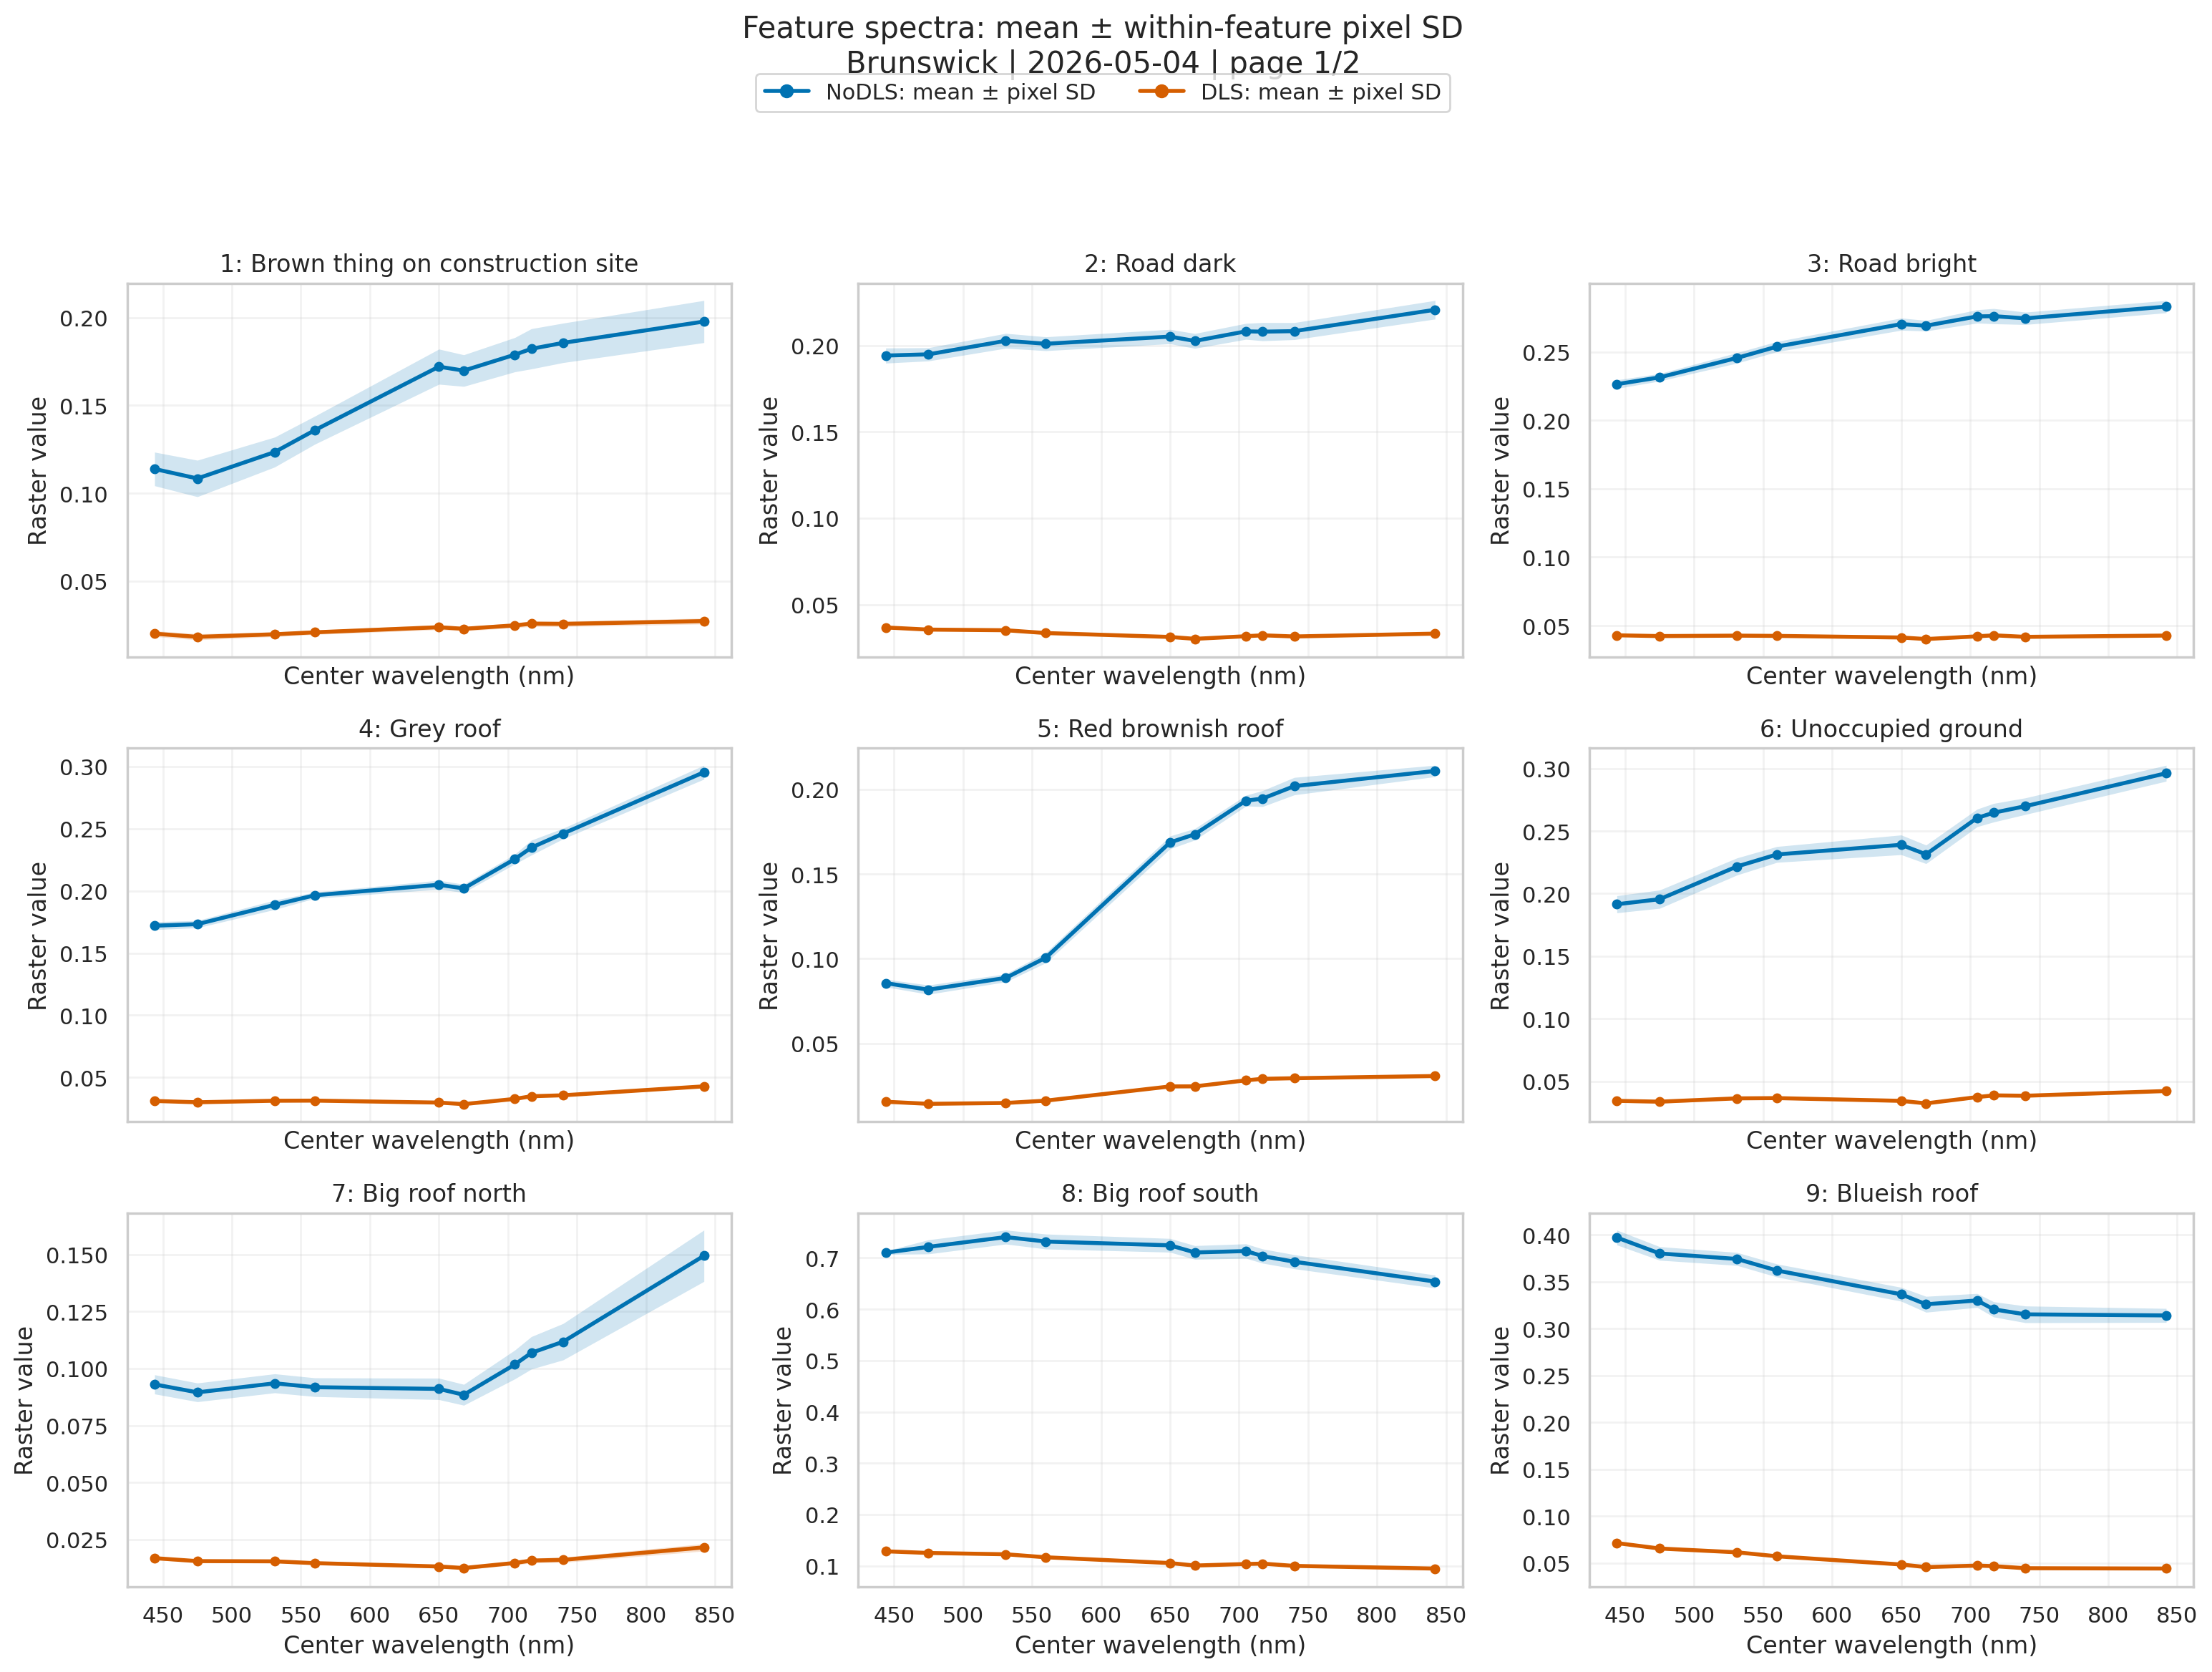

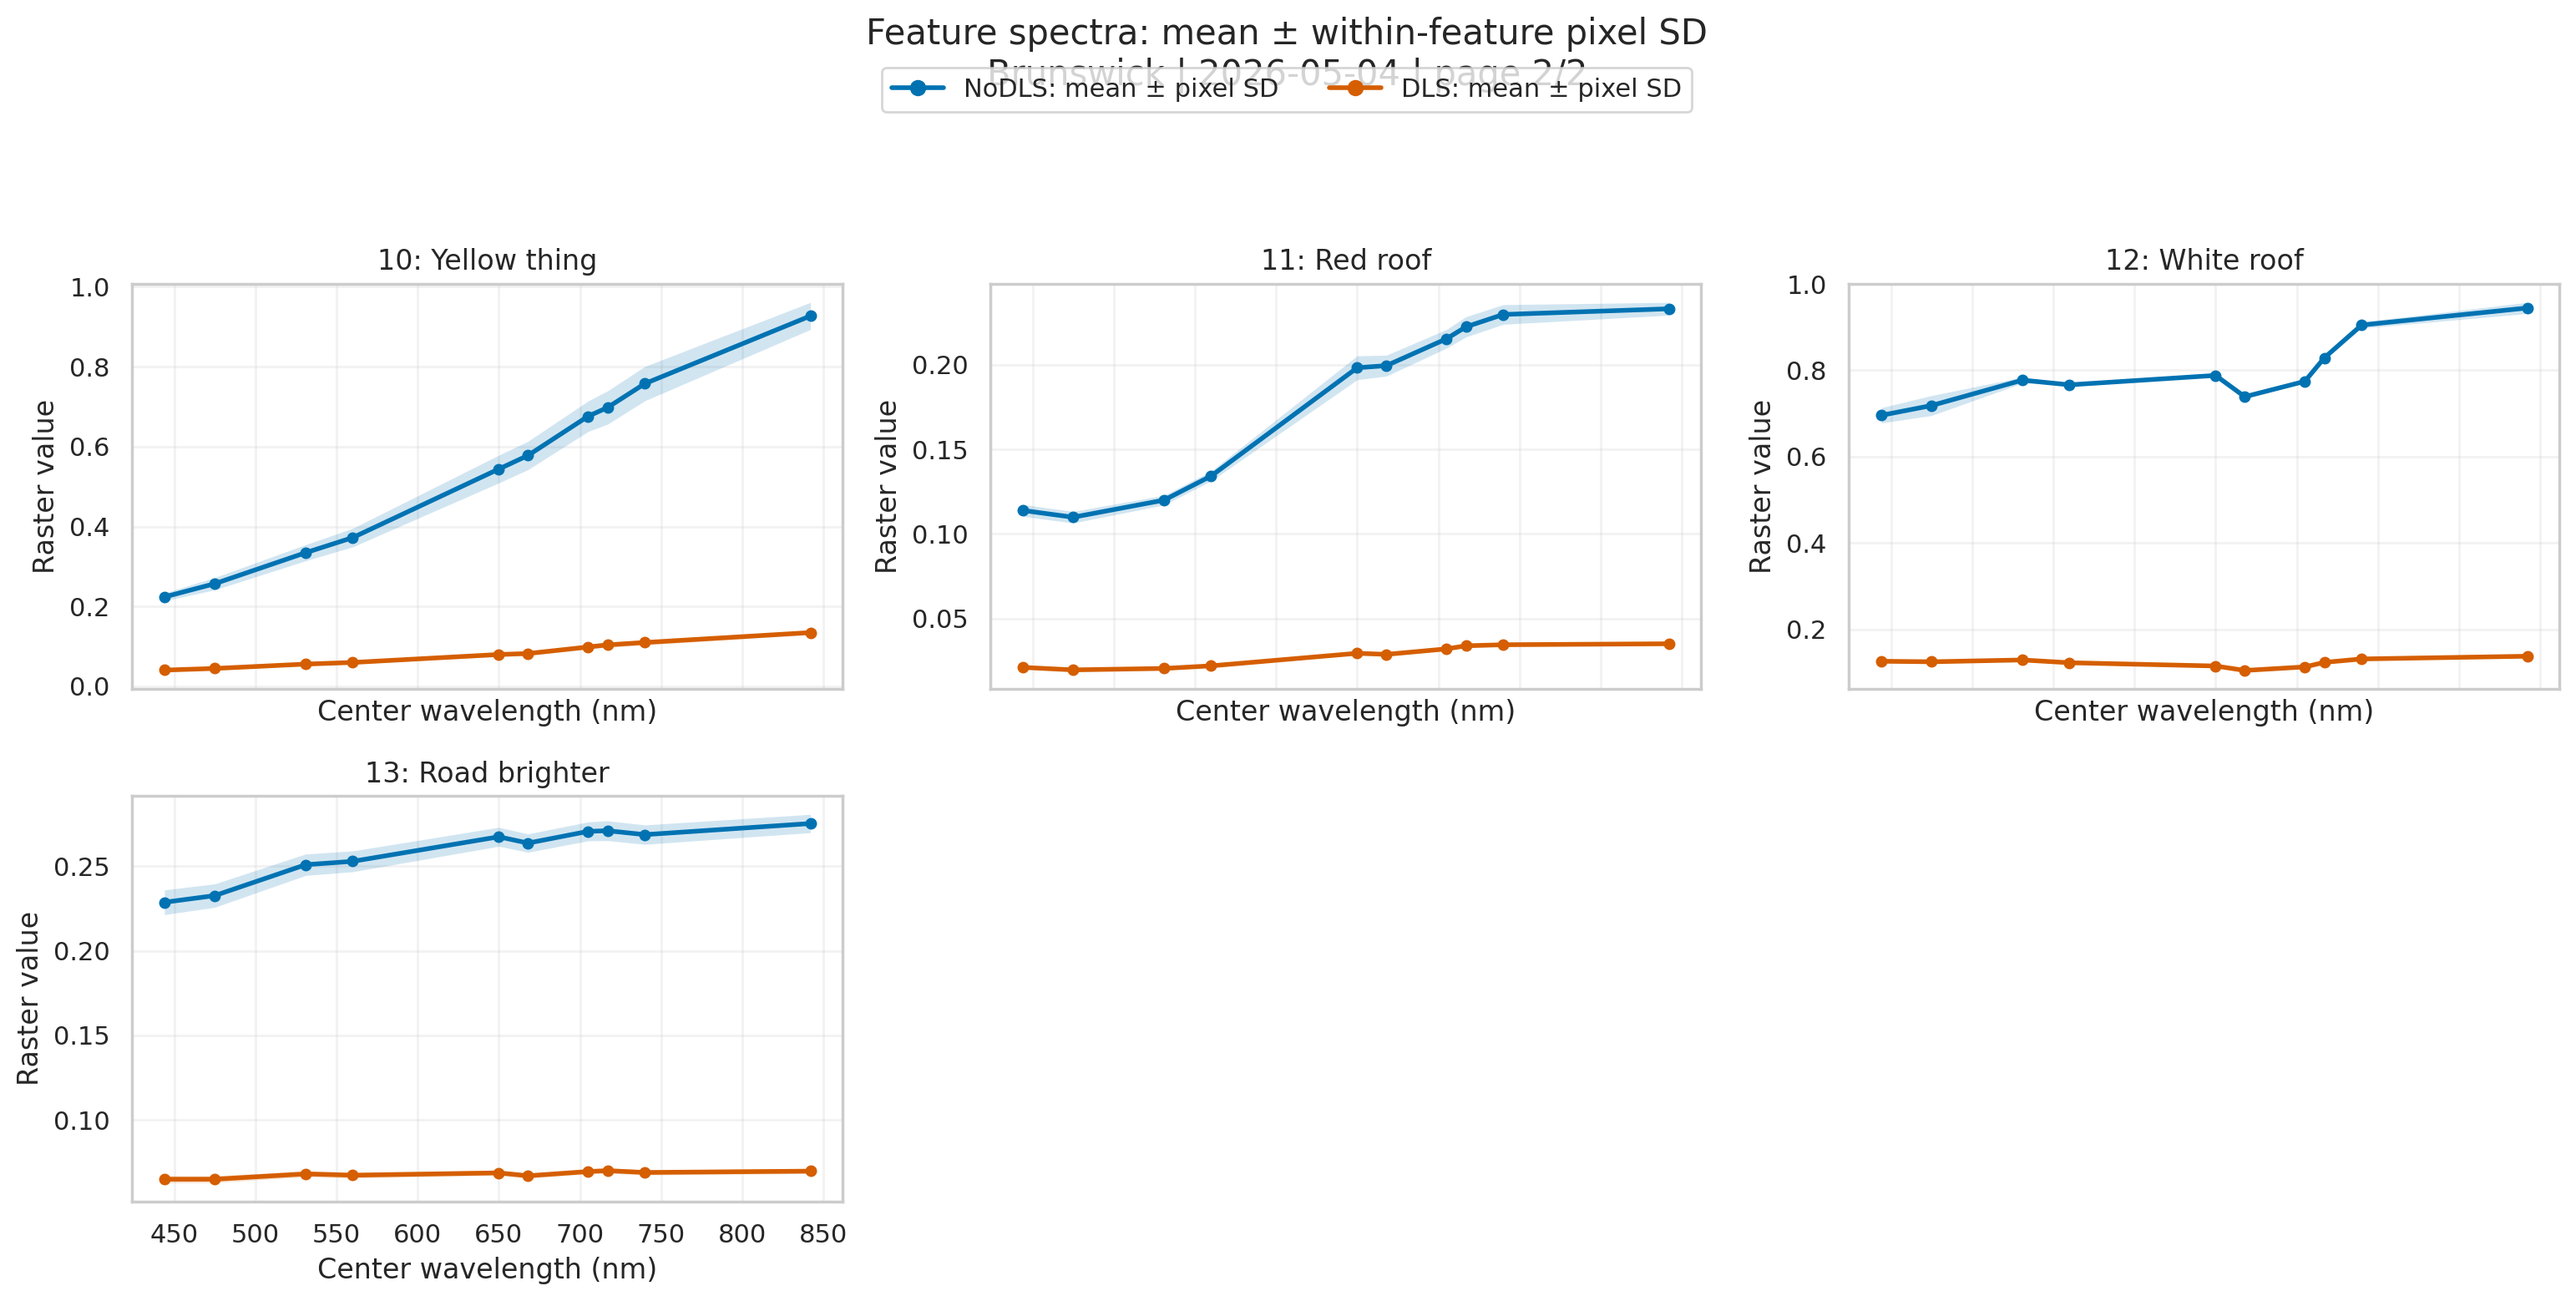

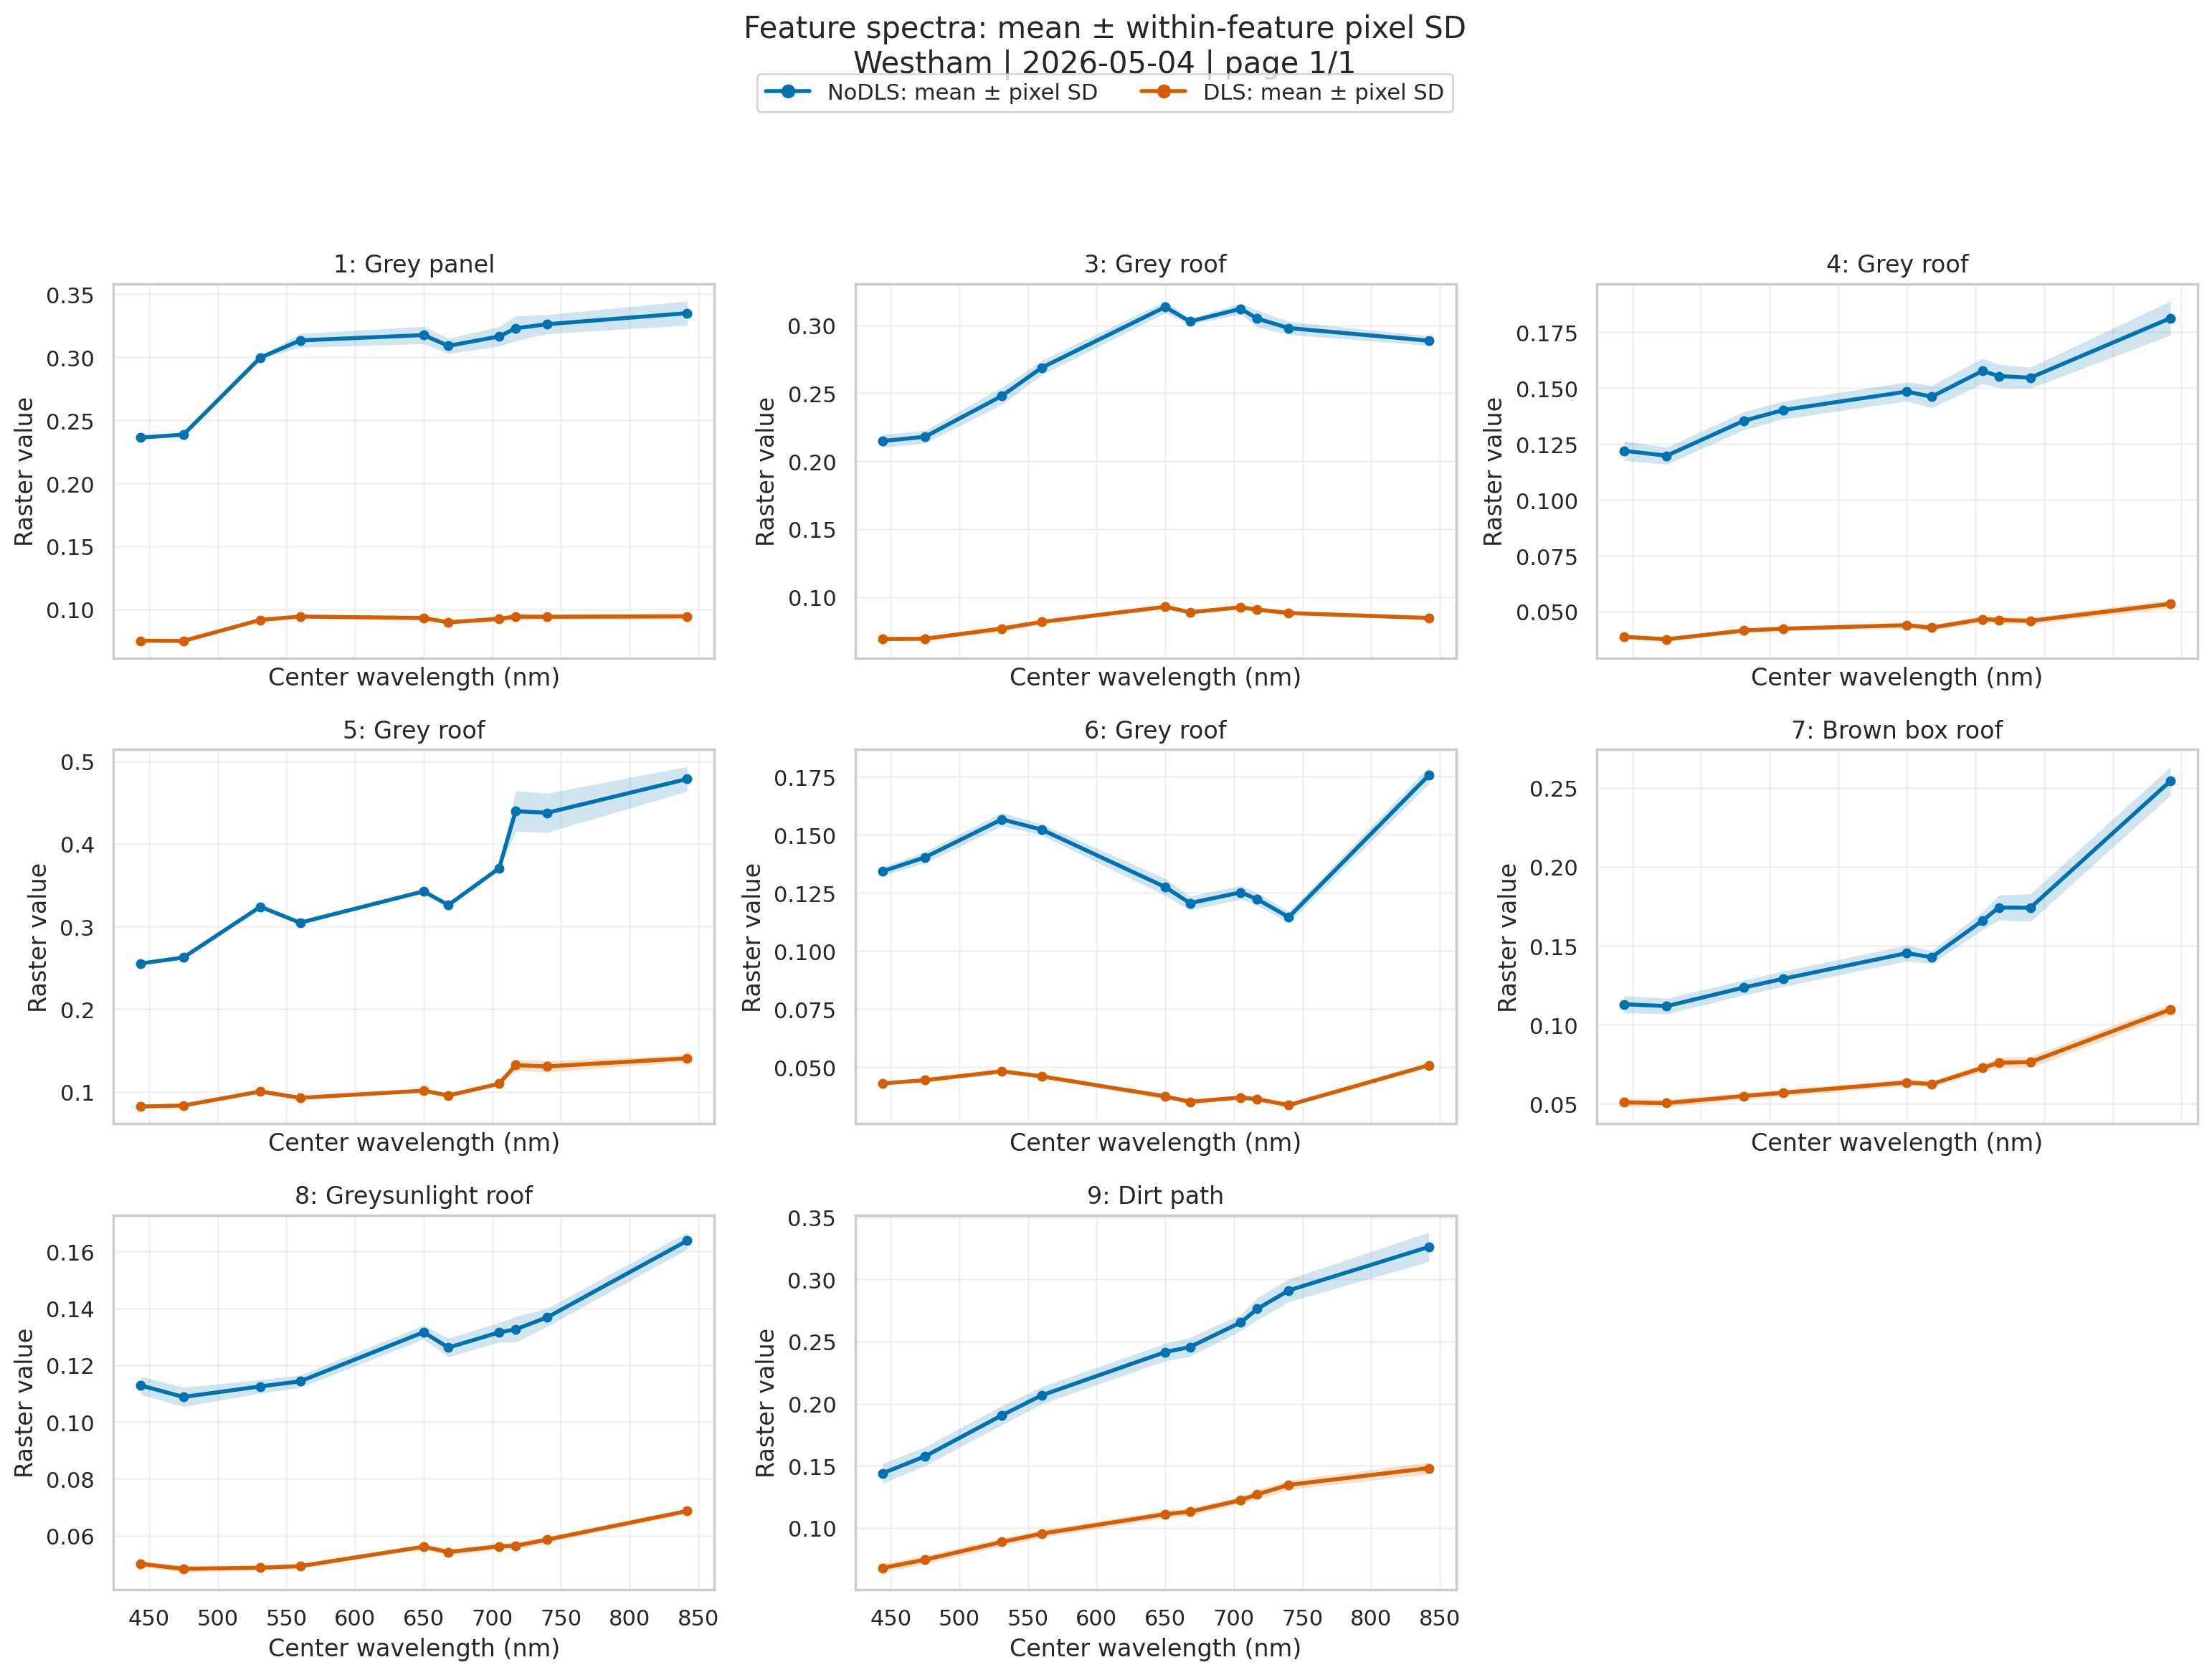

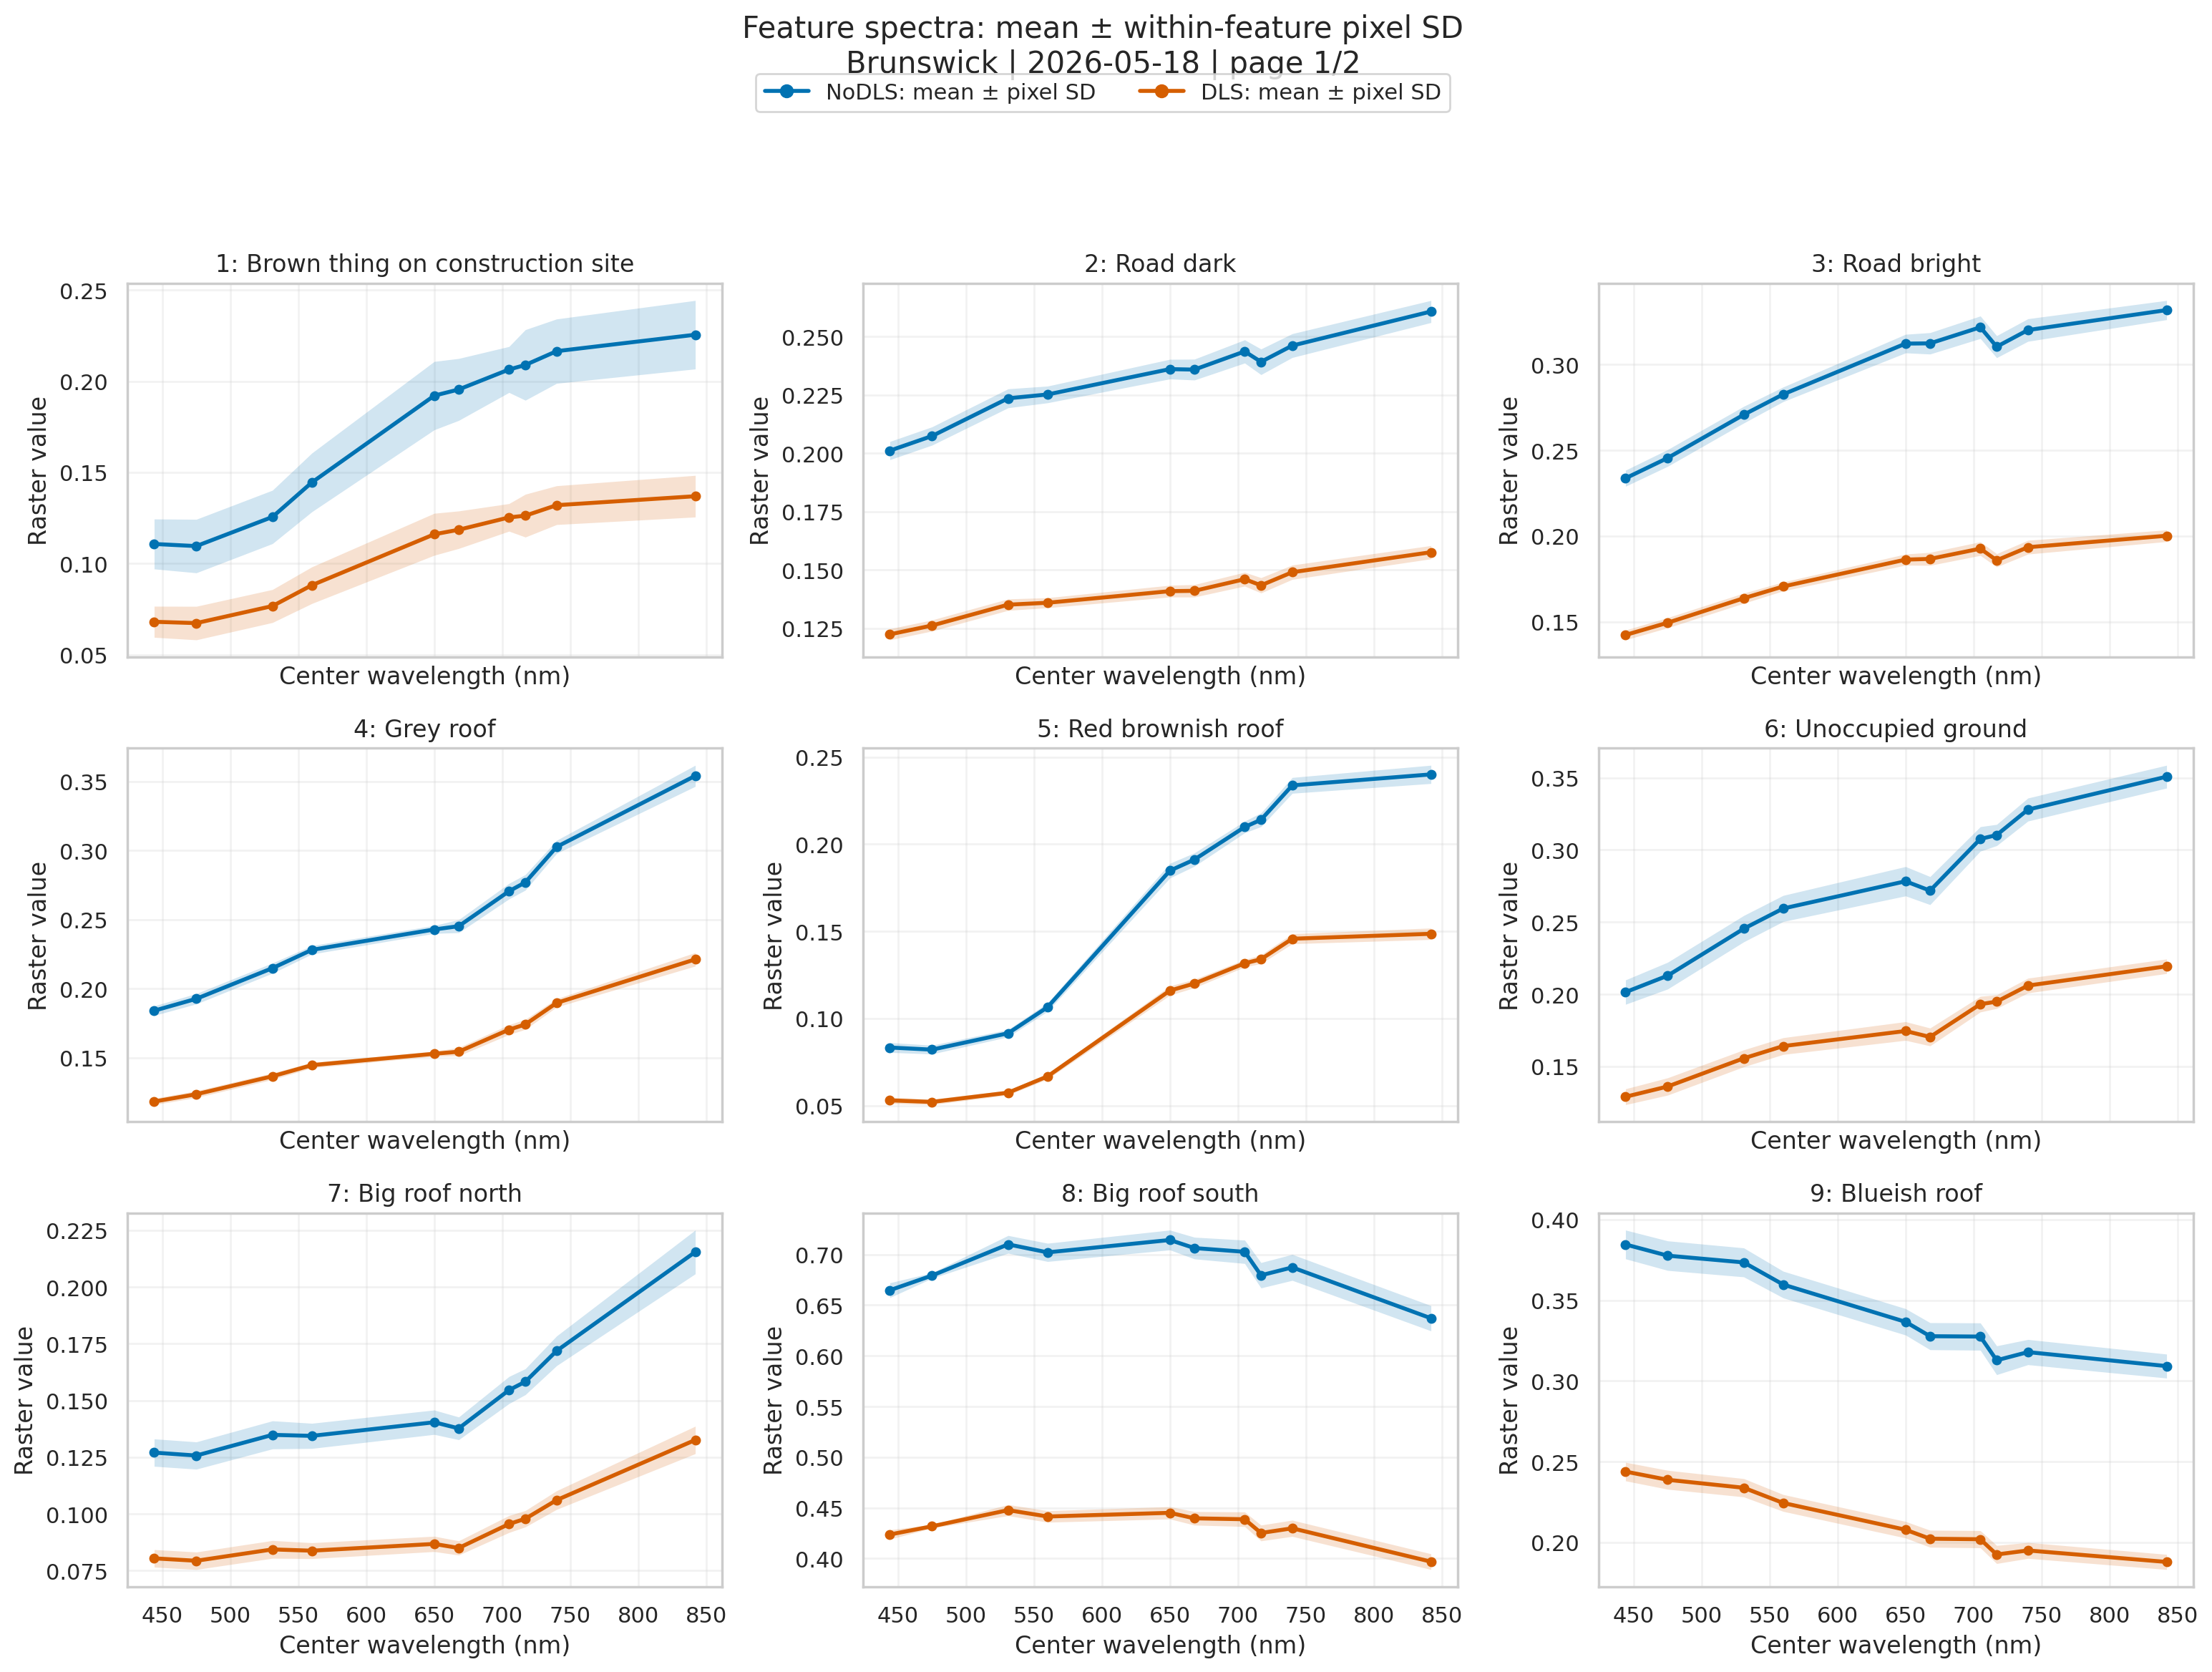

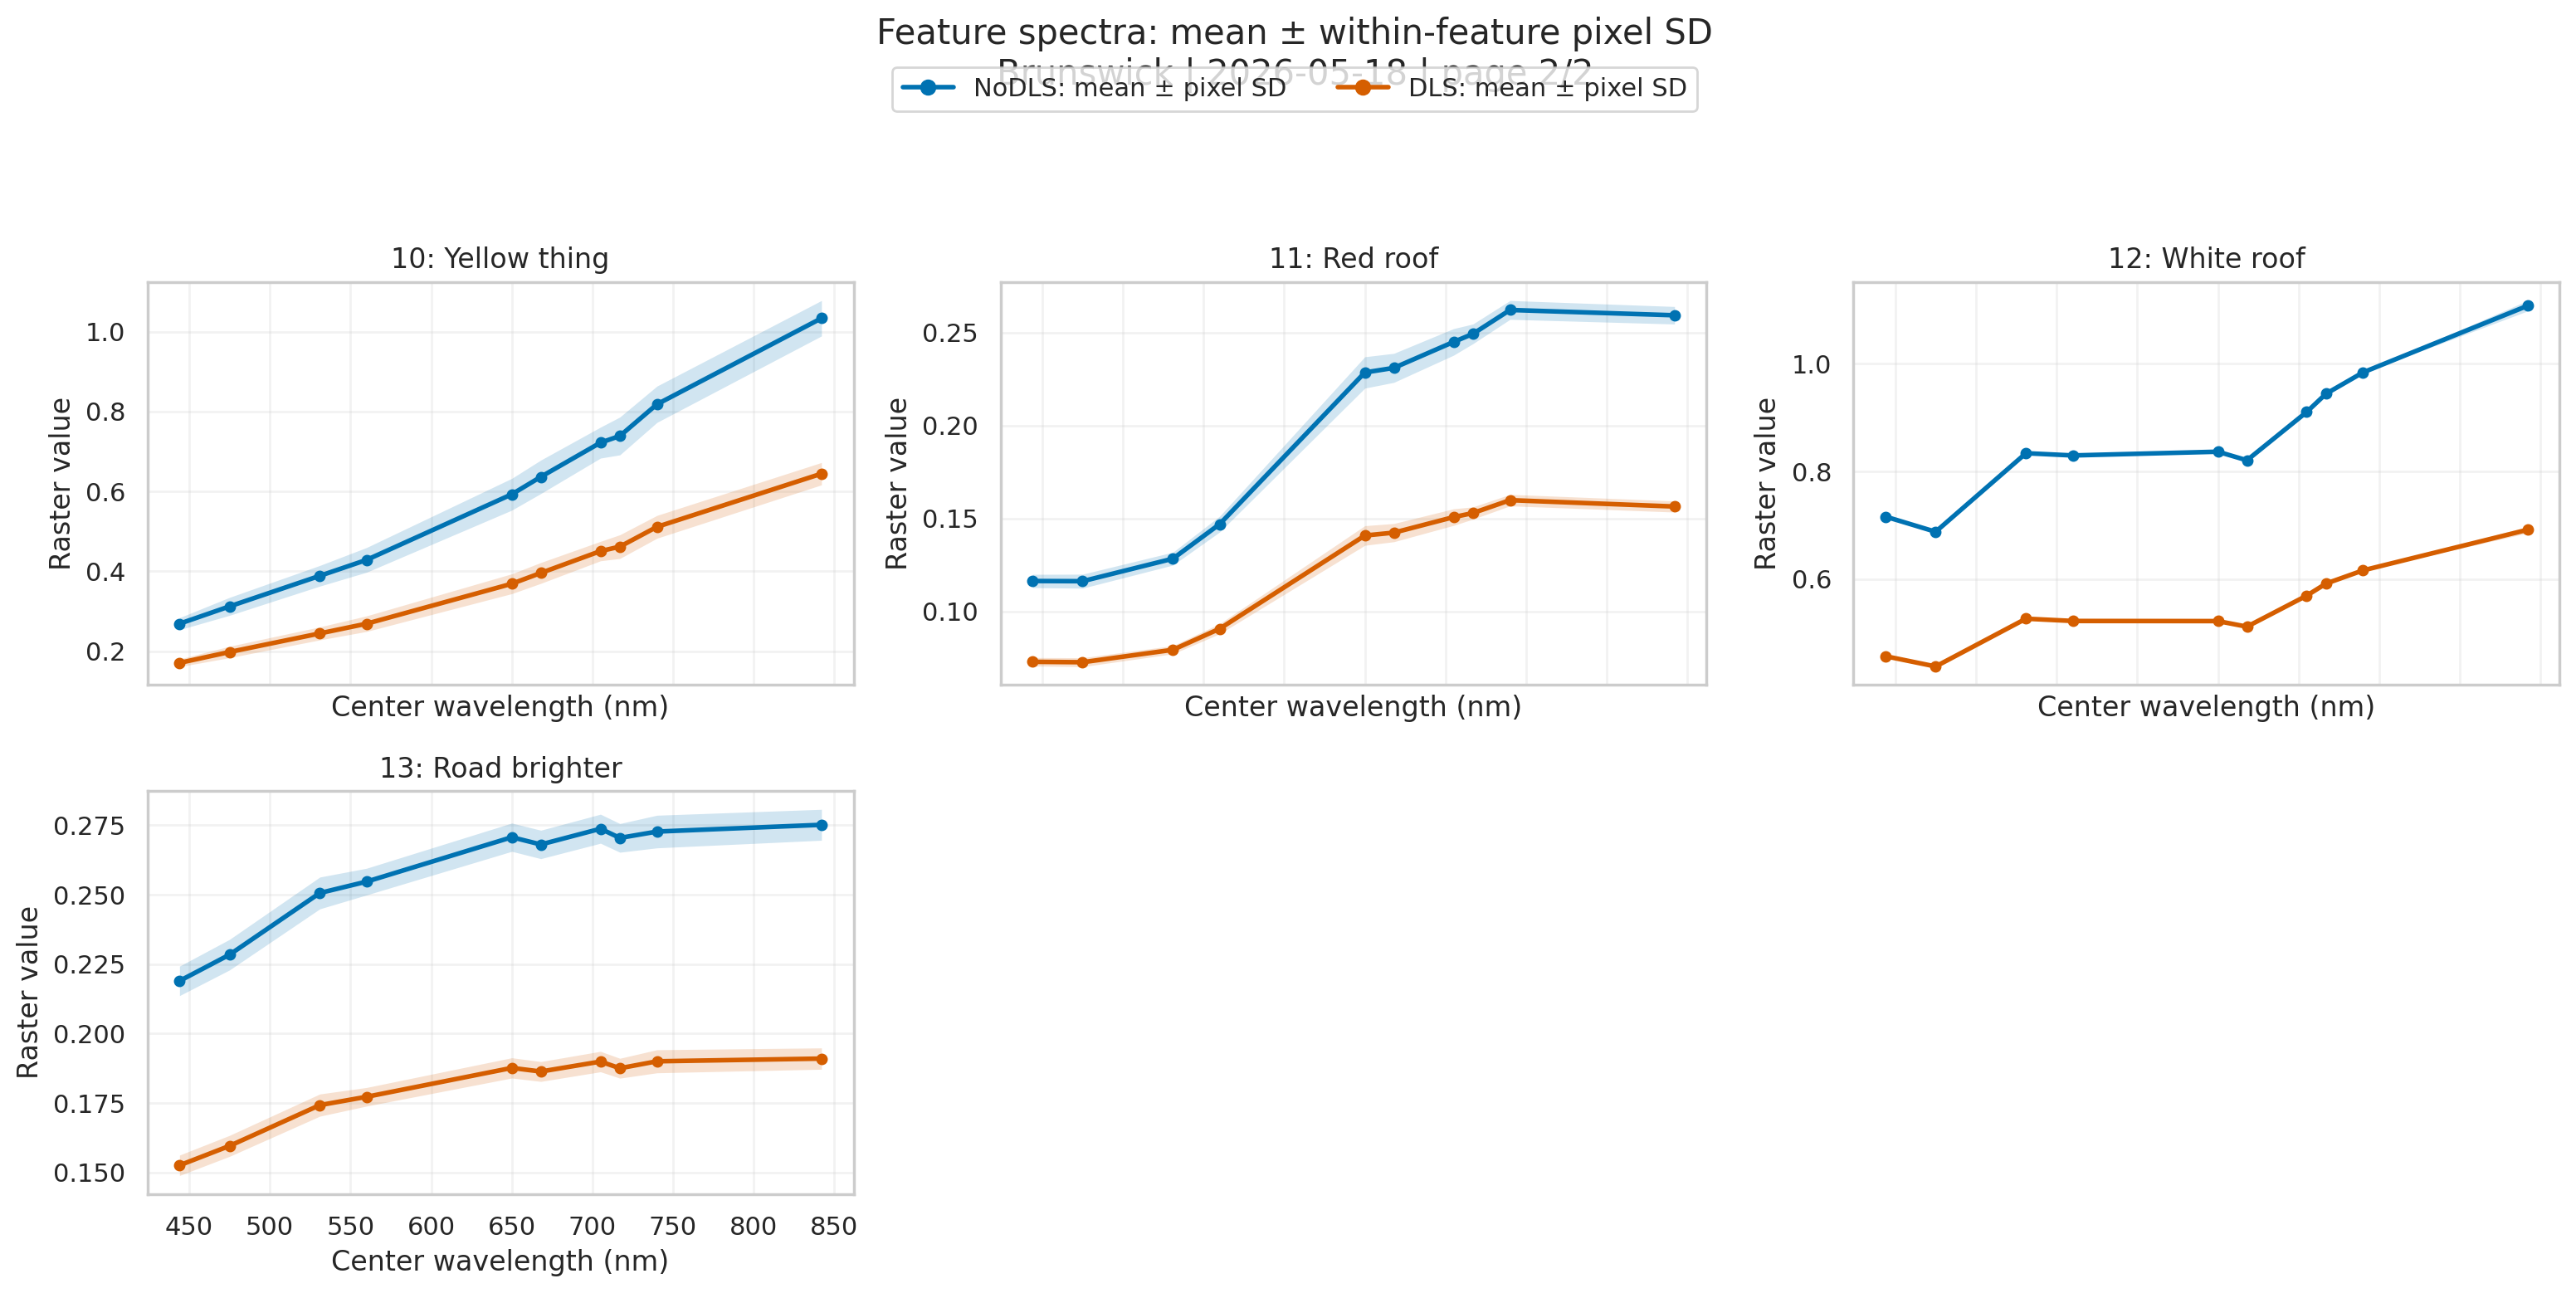

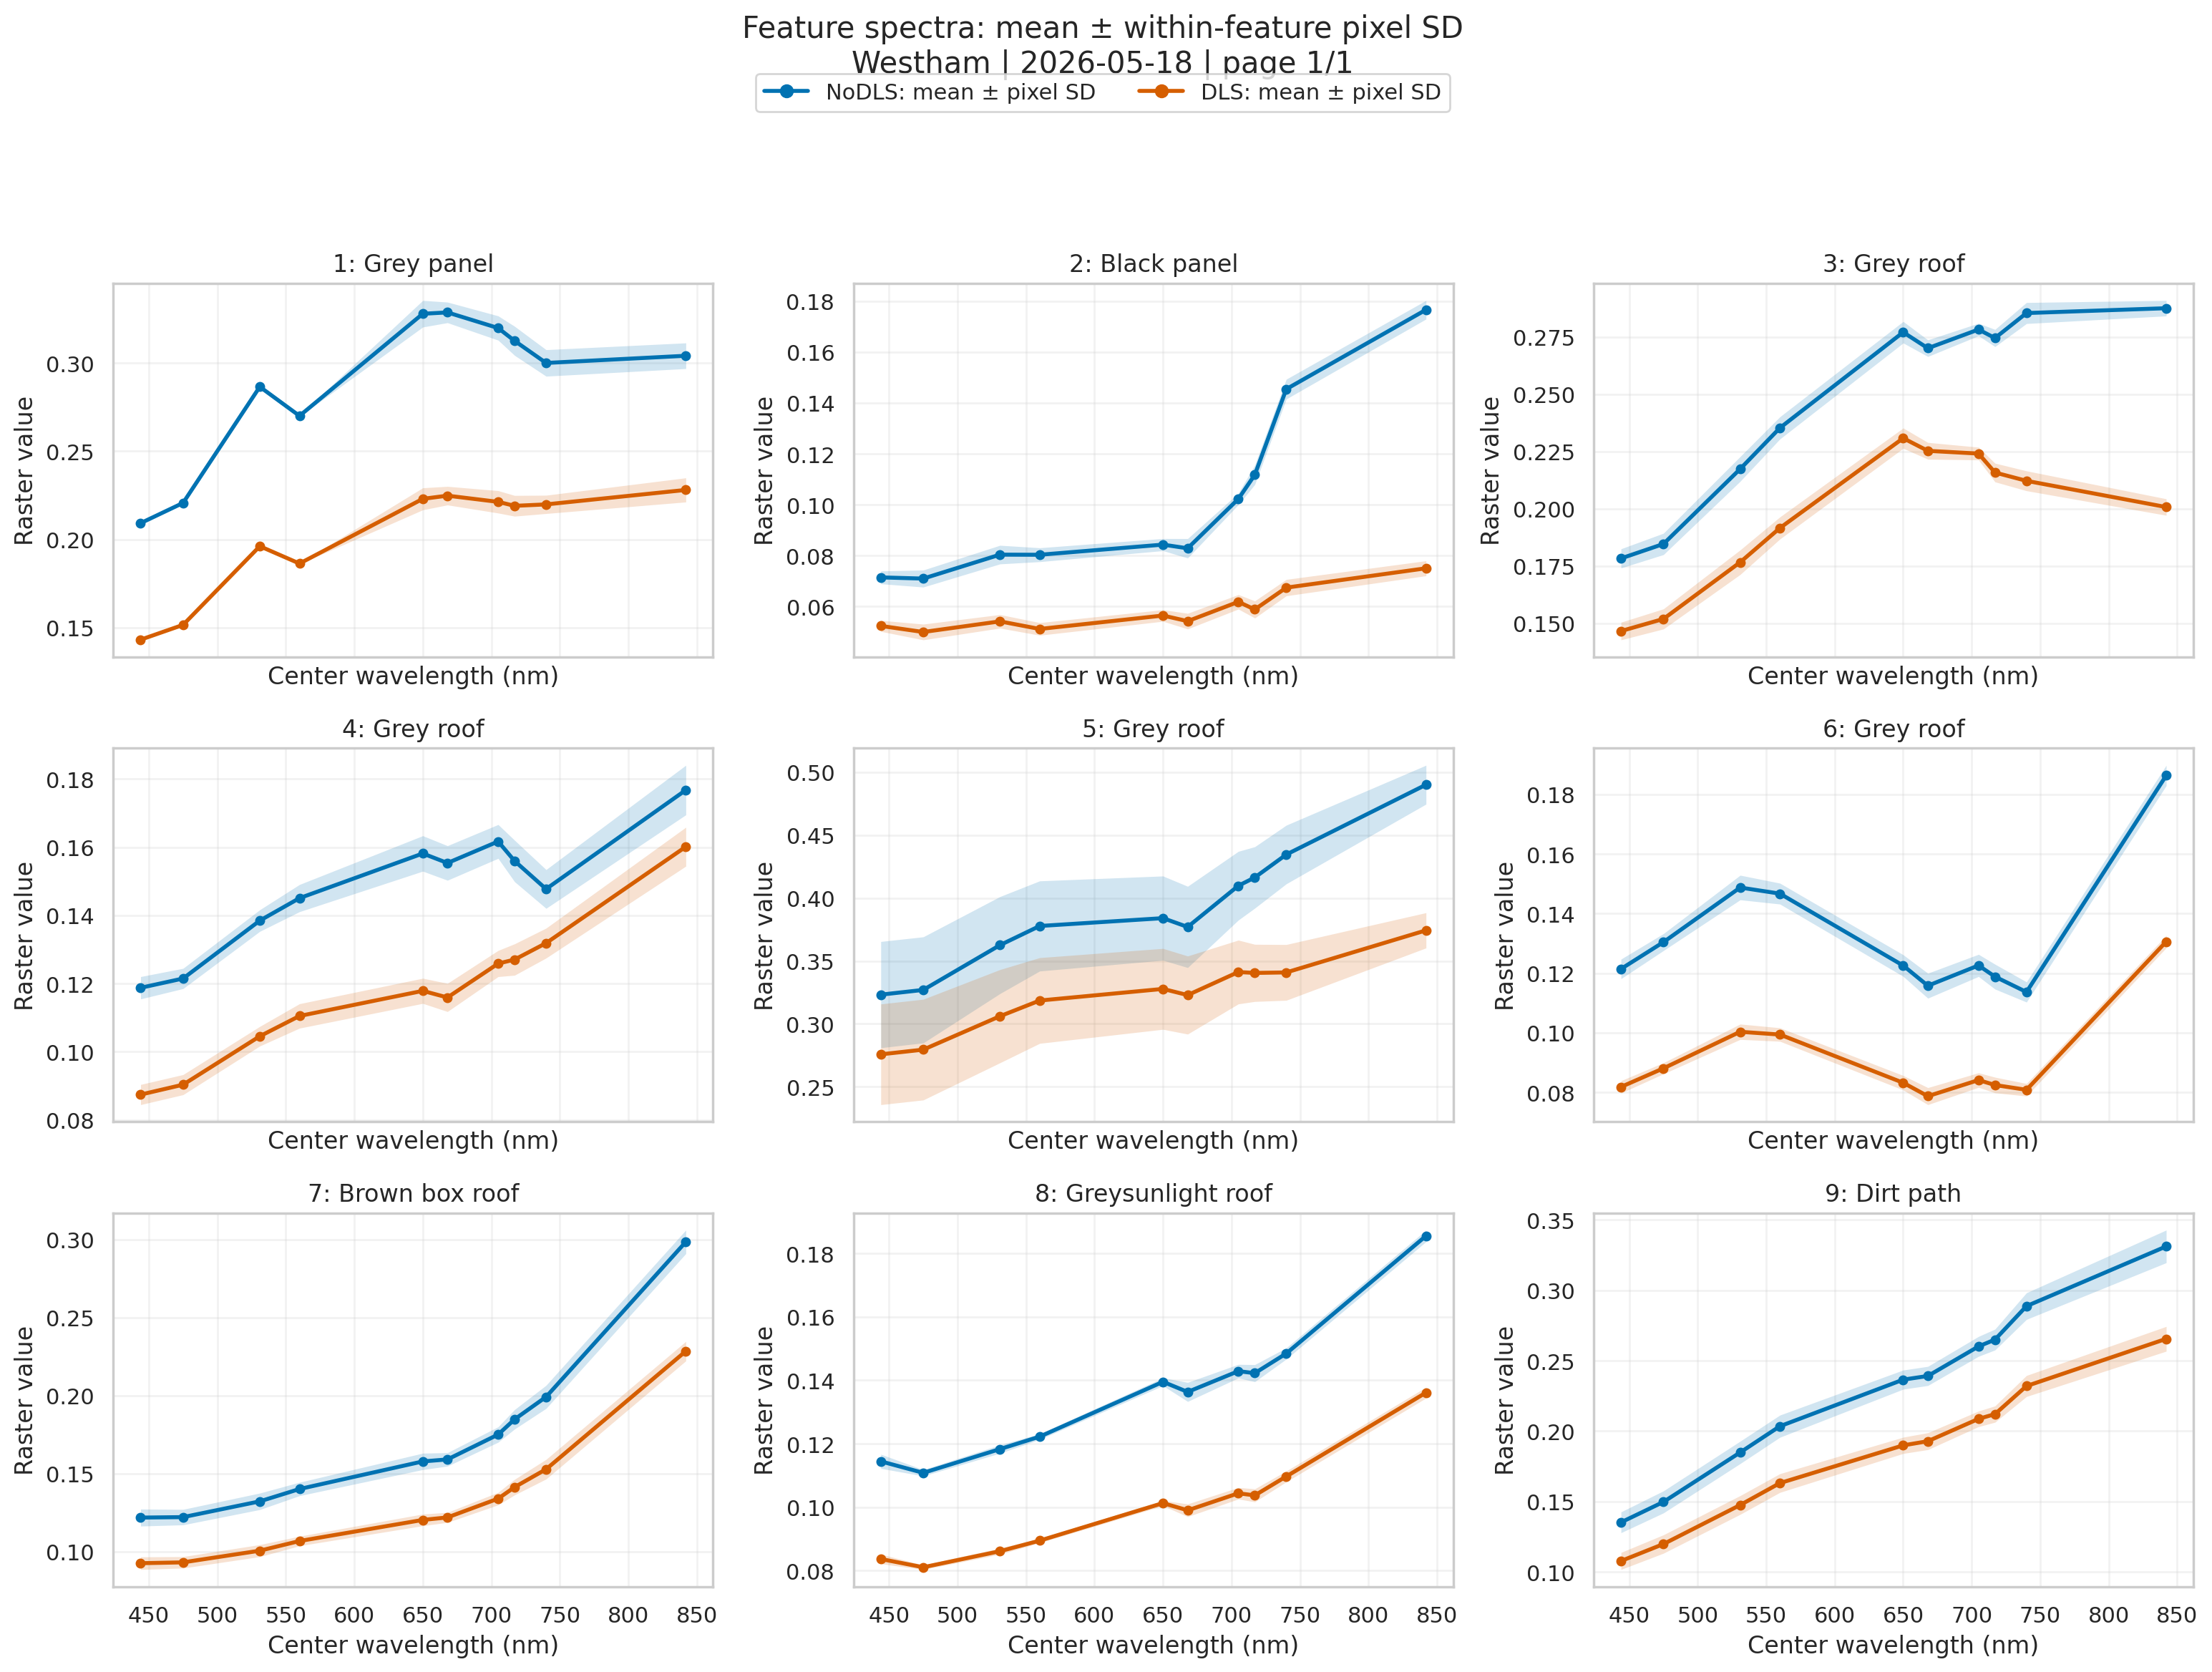

In [11]:
N_COLUMNS = 3
FEATURES_PER_FIGURE = 3 * N_COLUMNS

DLS_ORDER = ["NoDLS", "DLS"]
DLS_COLORS = {
    "NoDLS": "#0072B2",
    "DLS": "#D55E00",
}


def natural_sort_key(value):
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", str(value))
    ]


spectral_summary = (
    polygon_band_summary.loc[
        ~polygon_band_summary["is_pan"]
        & polygon_band_summary["wavelength_nm"].notna()
    ]
    .copy()
)

for flight_date in sorted(spectral_summary["flight_date"].unique()):
    for site in sorted(spectral_summary["site"].unique()):
        image_data = (
            spectral_summary.loc[
                spectral_summary["flight_date"].eq(flight_date)
                & spectral_summary["site"].eq(site)
            ]
            .sort_values(
                ["feature_id", "dls_mode", "wavelength_nm"]
            )
        )

        if image_data.empty:
            continue

        feature_ids = sorted(
            image_data["feature_id"].dropna().astype(str).unique(),
            key=natural_sort_key,
        )

        for page_start in range(
            0, len(feature_ids), FEATURES_PER_FIGURE
        ):
            page_features = feature_ids[
                page_start:page_start + FEATURES_PER_FIGURE
            ]
            n_features = len(page_features)
            ncols = min(N_COLUMNS, n_features)
            nrows = int(np.ceil(n_features / ncols))

            fig, axes = plt.subplots(
                nrows,
                ncols,
                figsize=(5.2 * ncols, 3.8 * nrows),
                sharex=True,
                sharey=False,
                squeeze=False,
            )
            axes = axes.ravel()

            for ax, feature_id in zip(axes, page_features):
                feature_data = image_data.loc[
                    image_data["feature_id"].astype(str).eq(feature_id)
                ]

                for dls_mode in DLS_ORDER:
                    mode_data = (
                        feature_data.loc[
                            feature_data["dls_mode"].eq(dls_mode)
                        ]
                        .sort_values("wavelength_nm")
                    )
                    if mode_data.empty:
                        continue

                    wavelength = mode_data[
                        "wavelength_nm"
                    ].to_numpy(dtype=float)
                    mean = mode_data["mean"].to_numpy(dtype=float)
                    std = mode_data["std"].fillna(0).to_numpy(dtype=float)
                    color = DLS_COLORS[dls_mode]

                    ax.plot(
                        wavelength,
                        mean,
                        color=color,
                        marker="o",
                        markersize=4,
                        linewidth=2,
                    )
                    ax.fill_between(
                        wavelength,
                        mean - std,
                        mean + std,
                        color=color,
                        alpha=0.18,
                        linewidth=0,
                    )

                matching = polygon_layers[site].loc[
                    polygon_layers[site]["feature_id"]
                    .astype(str).eq(feature_id)
                ]
                description = (
                    str(matching.iloc[0]["description"])
                    if not matching.empty else ""
                )

                ax.set_title(
                    f"{feature_id}: {description.capitalize()}"
                )
                ax.set_xlabel("Center wavelength (nm)")
                ax.set_ylabel("Raster value")
                ax.grid(True, alpha=0.25)

            for ax in axes[n_features:]:
                ax.remove()

            legend_handles = [
                Line2D(
                    [0], [0],
                    color=DLS_COLORS[mode],
                    marker="o",
                    linewidth=2,
                    label=f"{mode}: mean ± pixel SD",
                )
                for mode in DLS_ORDER
            ]

            page_number = page_start // FEATURES_PER_FIGURE + 1
            page_count = int(
                np.ceil(len(feature_ids) / FEATURES_PER_FIGURE)
            )

            fig.legend(
                handles=legend_handles,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.995),
                ncol=2,
            )
            fig.suptitle(
                "Feature spectra: mean ± within-feature pixel SD\n"
                f"{site.title()} | {flight_date} | "
                f"page {page_number}/{page_count}",
                y=1.025,
                fontsize=15,
            )
            fig.tight_layout(rect=(0, 0, 1, 0.95))
            plt.show()

## 11. Pair DLS and NoDLS polygon means

In [12]:
paired_dls = (
    polygon_band_summary
    .pivot_table(
        index=[
            "flight_date",
            "site",
            "feature_id",
            "band_name",
            "source_band",
            "is_pan",
        ],
        columns="dls_mode",
        values="mean",
        aggfunc="first",
    )
    .reset_index()
    .merge(
        BAND_METADATA[
            [
                "band_name",
                "source_band",
                "wavelength_nm",
                "is_pan",
            ]
        ],
        on=["band_name", "source_band", "is_pan"],
        how="left",
        validate="many_to_one",
    )
)
paired_dls.columns.name = None

paired_dls["difference_DLS_minus_NoDLS"] = (
    paired_dls["DLS"] - paired_dls["NoDLS"]
)
paired_dls["ratio_DLS_to_NoDLS"] = np.where(
    paired_dls["NoDLS"].abs() > 0,
    paired_dls["DLS"] / paired_dls["NoDLS"],
    np.nan,
)
paired_dls["percent_difference"] = np.where(
    paired_dls["NoDLS"].abs() > 0,
    100 * (
        paired_dls["DLS"] - paired_dls["NoDLS"]
    ) / paired_dls["NoDLS"],
    np.nan,
)

display(paired_dls.head())

if SAVE_OUTPUTS:
    paired_dls.to_parquet(
        OUTPUT_DIR / "paired_DLS_NoDLS_polygon_means.parquet",
        index=False,
    )

,flight_date,site,feature_id,band_name,source_band,is_pan,DLS,NoDLS,wavelength_nm,difference_DLS_minus_NoDLS,ratio_DLS_to_NoDLS,percent_difference
0,2026-05-04,brunswick,1,B1,1,False,0.020121,0.113850,444.0,-0.093729,0.176736,-82.326448
1,2026-05-04,brunswick,1,B10,11,False,0.027272,0.197727,842.0,-0.170455,0.137930,-86.207049
2,2026-05-04,brunswick,1,B2,2,False,0.018316,0.108424,475.0,-0.090108,0.168931,-83.106883
3,2026-05-04,brunswick,1,B3,3,False,0.019767,0.123458,531.0,-0.103691,0.160111,-83.988863
4,2026-05-04,brunswick,1,B4,4,False,0.020891,0.135875,560.0,-0.114983,0.153755,-84.624487


## 12. DLS versus NoDLS agreement metrics

In [13]:
def agreement_metrics(group):
    valid = group[["NoDLS", "DLS"]].dropna()

    if valid.empty:
        return pd.Series({
            "n": 0,
            "bias": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "r2": np.nan,
            "mean_ratio": np.nan,
        })

    reference = valid["NoDLS"].to_numpy()
    estimate = valid["DLS"].to_numpy()
    residual = estimate - reference

    return pd.Series({
        "n": len(valid),
        "bias": residual.mean(),
        "mae": np.abs(residual).mean(),
        "rmse": np.sqrt(np.mean(residual ** 2)),
        "r2": (
            r2_score(reference, estimate)
            if len(valid) >= 2 else np.nan
        ),
        "mean_ratio": np.nanmean(
            np.divide(
                estimate,
                reference,
                out=np.full_like(
                    estimate, np.nan, dtype=float
                ),
                where=np.abs(reference) > 0,
            )
        ),
    })


dls_agreement = (
    paired_dls
    .groupby(
        [
            "flight_date", "site", "band_name",
            "source_band", "is_pan",
        ],
        observed=True,
    )
    .apply(agreement_metrics)
    .reset_index()
)
display(dls_agreement)

if SAVE_OUTPUTS:
    dls_agreement.to_csv(
        OUTPUT_DIR / "DLS_NoDLS_agreement_metrics.csv",
        index=False,
    )

/tmp/ipykernel_22016/755133370.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agreement_metrics)


,flight_date,site,band_name,source_band,is_pan,n,bias,mae,rmse,r2,mean_ratio
0,2026-05-04,brunswick,B1,1,False,13.0,-0.215063,0.215063,0.271821,-0.804458,0.190016
1,2026-05-04,brunswick,B10,11,False,13.0,-0.326498,0.326498,0.396558,-1.288773,0.153582
2,2026-05-04,brunswick,B2,2,False,13.0,-0.219961,0.219961,0.279294,-0.809068,0.183043
3,2026-05-04,brunswick,B3,3,False,13.0,-0.239151,0.239151,0.300201,-0.916006,0.174821
4,2026-05-04,brunswick,B4,4,False,13.0,-0.245319,0.245319,0.303126,-1.059611,0.168751
5,2026-05-04,brunswick,B5,6,False,13.0,-0.274204,0.274204,0.328924,-1.411273,0.154652
6,2026-05-04,brunswick,B6,7,False,13.0,-0.271766,0.271766,0.324319,-1.495130,0.150867
7,2026-05-04,brunswick,B7,8,False,13.0,-0.288312,0.288312,0.342815,-1.518848,0.154520
8,2026-05-04,brunswick,B8,9,False,13.0,-0.293048,0.293048,0.350442,-1.433169,0.157400
9,2026-05-04,brunswick,B9,10,False,13.0,-0.304535,0.304535,0.368774,-1.322201,0.153936


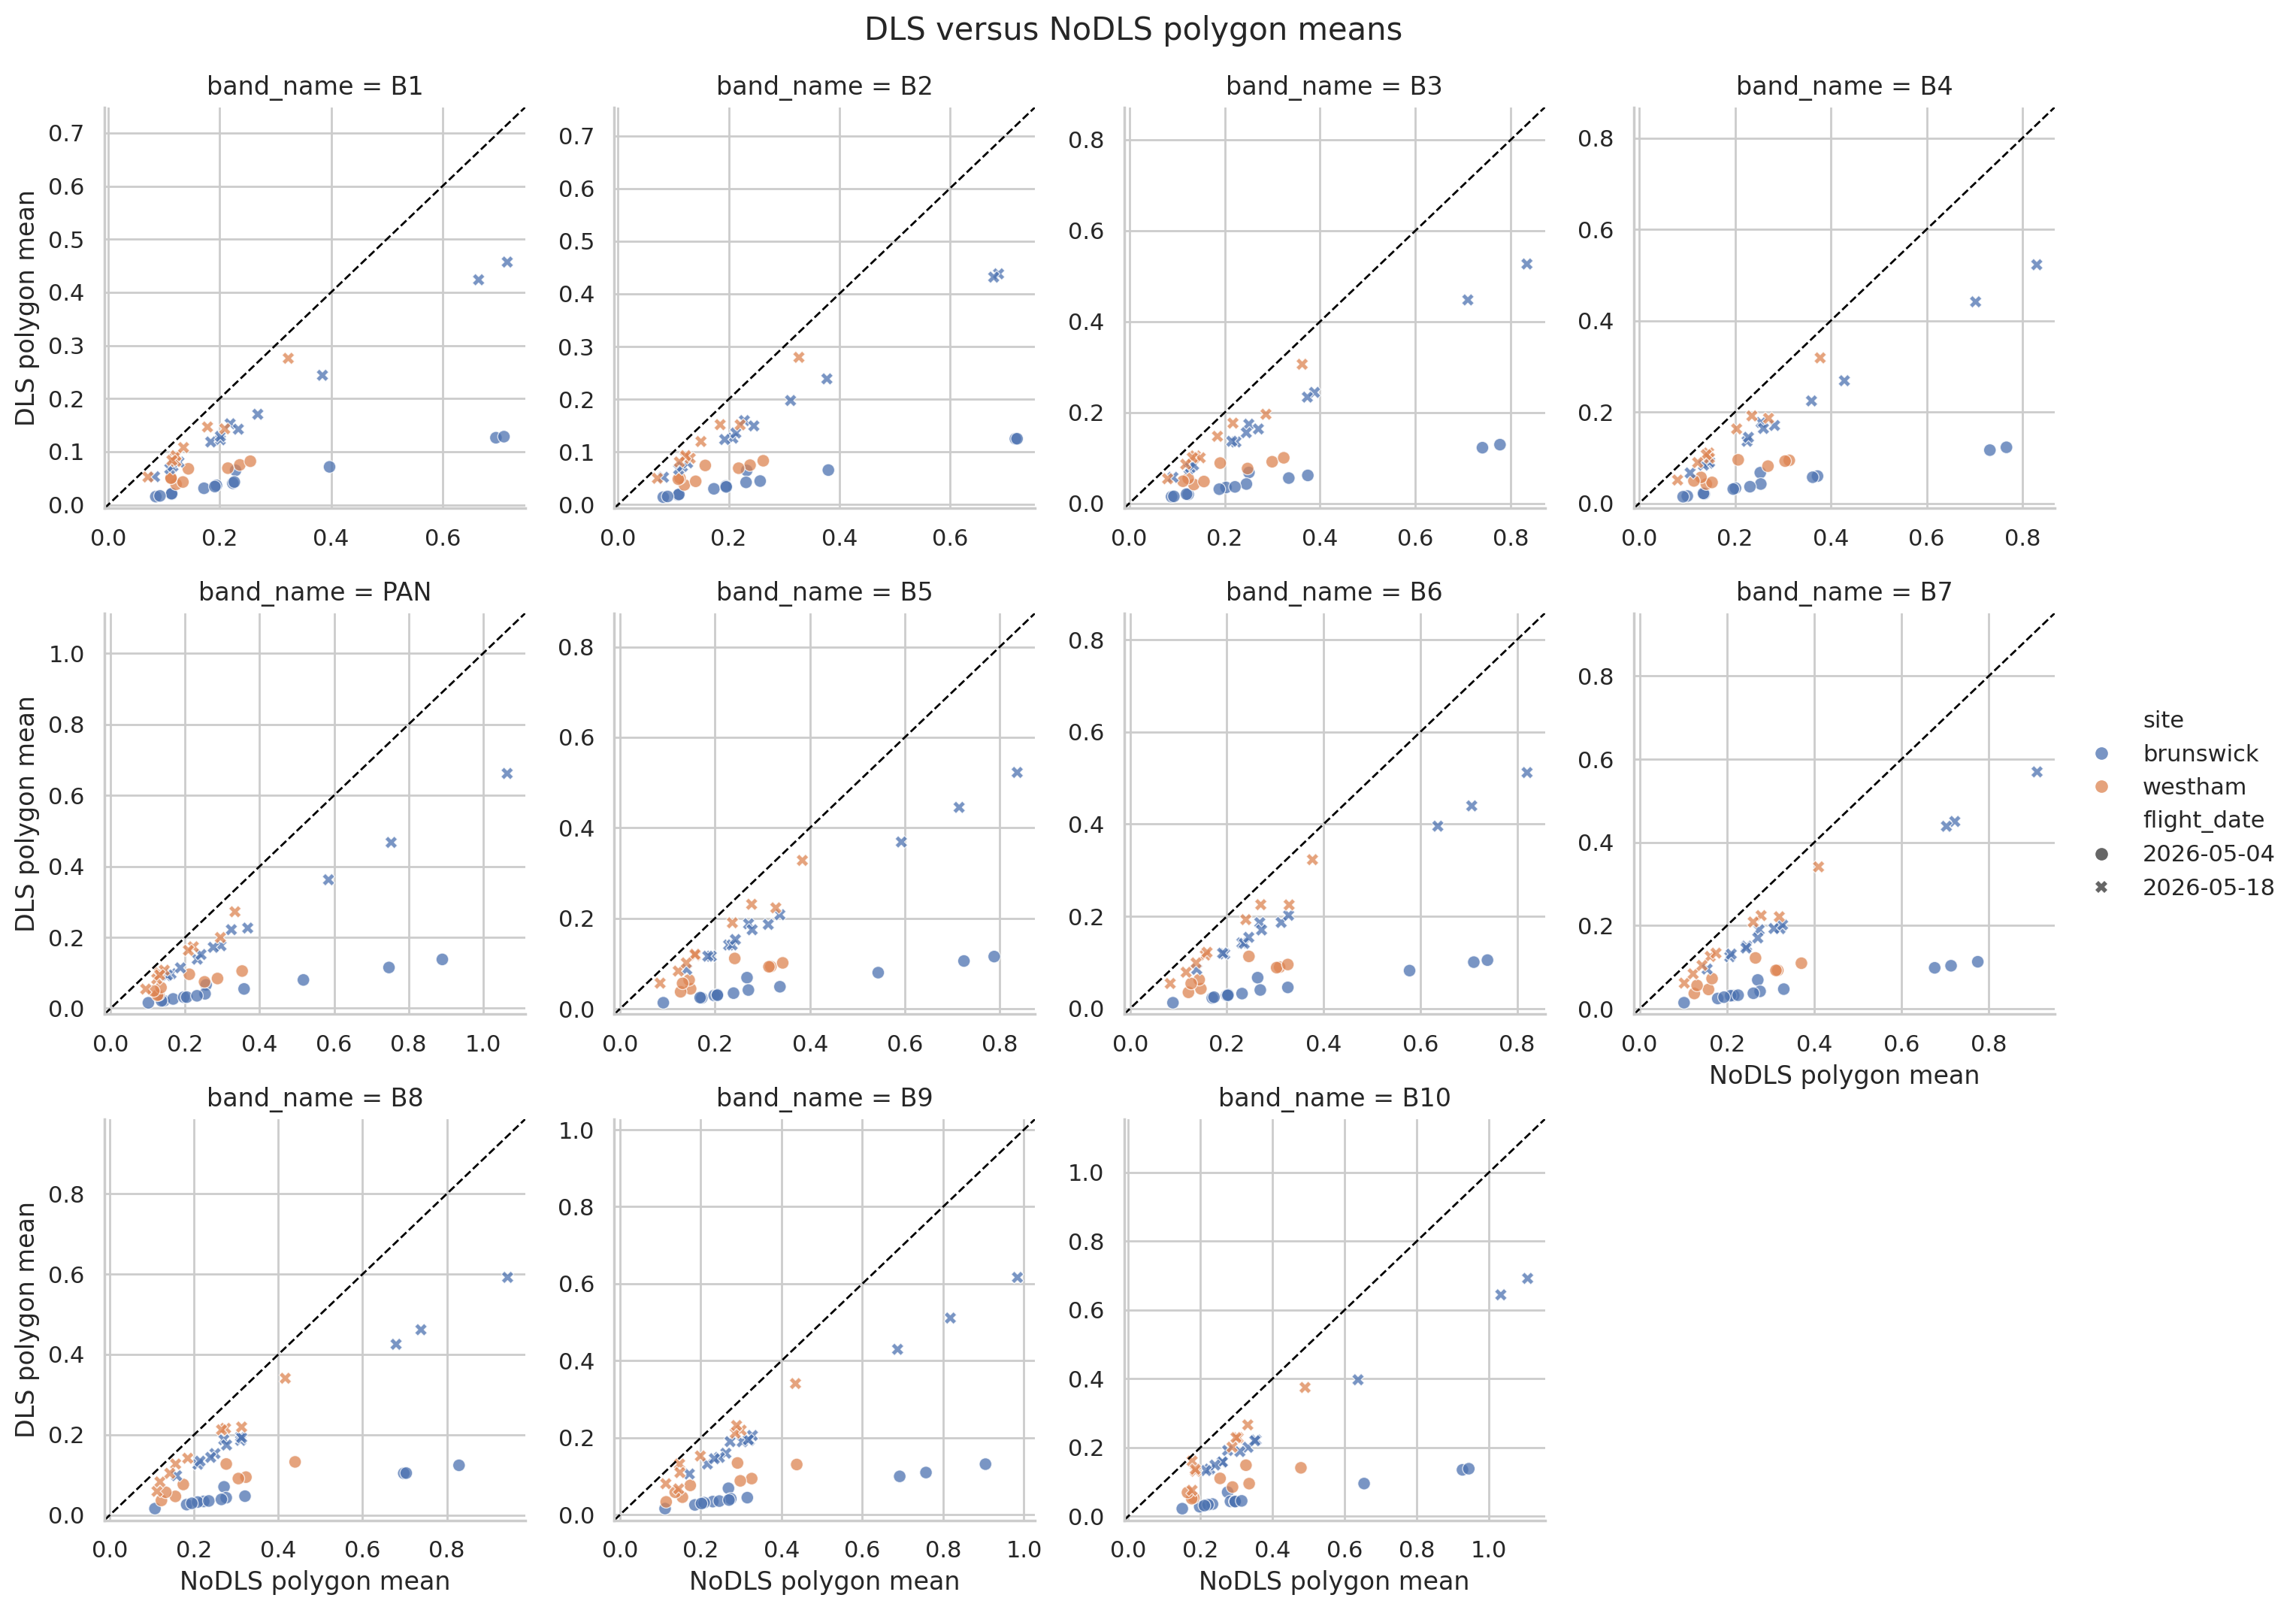

In [14]:
plot_pairs = paired_dls.dropna(
    subset=["DLS", "NoDLS"]
).copy()
plot_pairs["band_name"] = pd.Categorical(
    plot_pairs["band_name"],
    categories=SOURCE_BAND_NAMES,
    ordered=True,
)

g = sns.relplot(
    data=plot_pairs,
    x="NoDLS",
    y="DLS",
    hue="site",
    col="band_name",
    col_wrap=4,
    style="flight_date",
    height=3.5,
    facet_kws={"sharex": False, "sharey": False},
    alpha=0.75,
)

for ax in g.axes.flat:
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    low = min(xlim[0], ylim[0])
    high = max(xlim[1], ylim[1])
    ax.plot(
        [low, high], [low, high],
        "--", color="black", linewidth=1,
    )
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)

g.set_axis_labels(
    "NoDLS polygon mean",
    "DLS polygon mean",
)
g.fig.suptitle(
    "DLS versus NoDLS polygon means",
    y=1.02,
    fontsize=15,
)
plt.show()

## 14. Temporal repeatability: May 4 versus May 18

,site,dls_mode,feature_id,band_name,source_band,is_pan,2026-05-04,2026-05-18,wavelength_nm,difference_May18_minus_May04,ratio_May18_to_May04
0,brunswick,DLS,1,B1,1,False,0.020121,0.068007,444.0,0.047886,3.379846
1,brunswick,DLS,1,B10,11,False,0.027272,0.136914,842.0,0.109642,5.020258
2,brunswick,DLS,1,B2,2,False,0.018316,0.067280,475.0,0.048963,3.673240
3,brunswick,DLS,1,B3,3,False,0.019767,0.076642,531.0,0.056875,3.877237
4,brunswick,DLS,1,B4,4,False,0.020891,0.088079,560.0,0.067188,4.216039


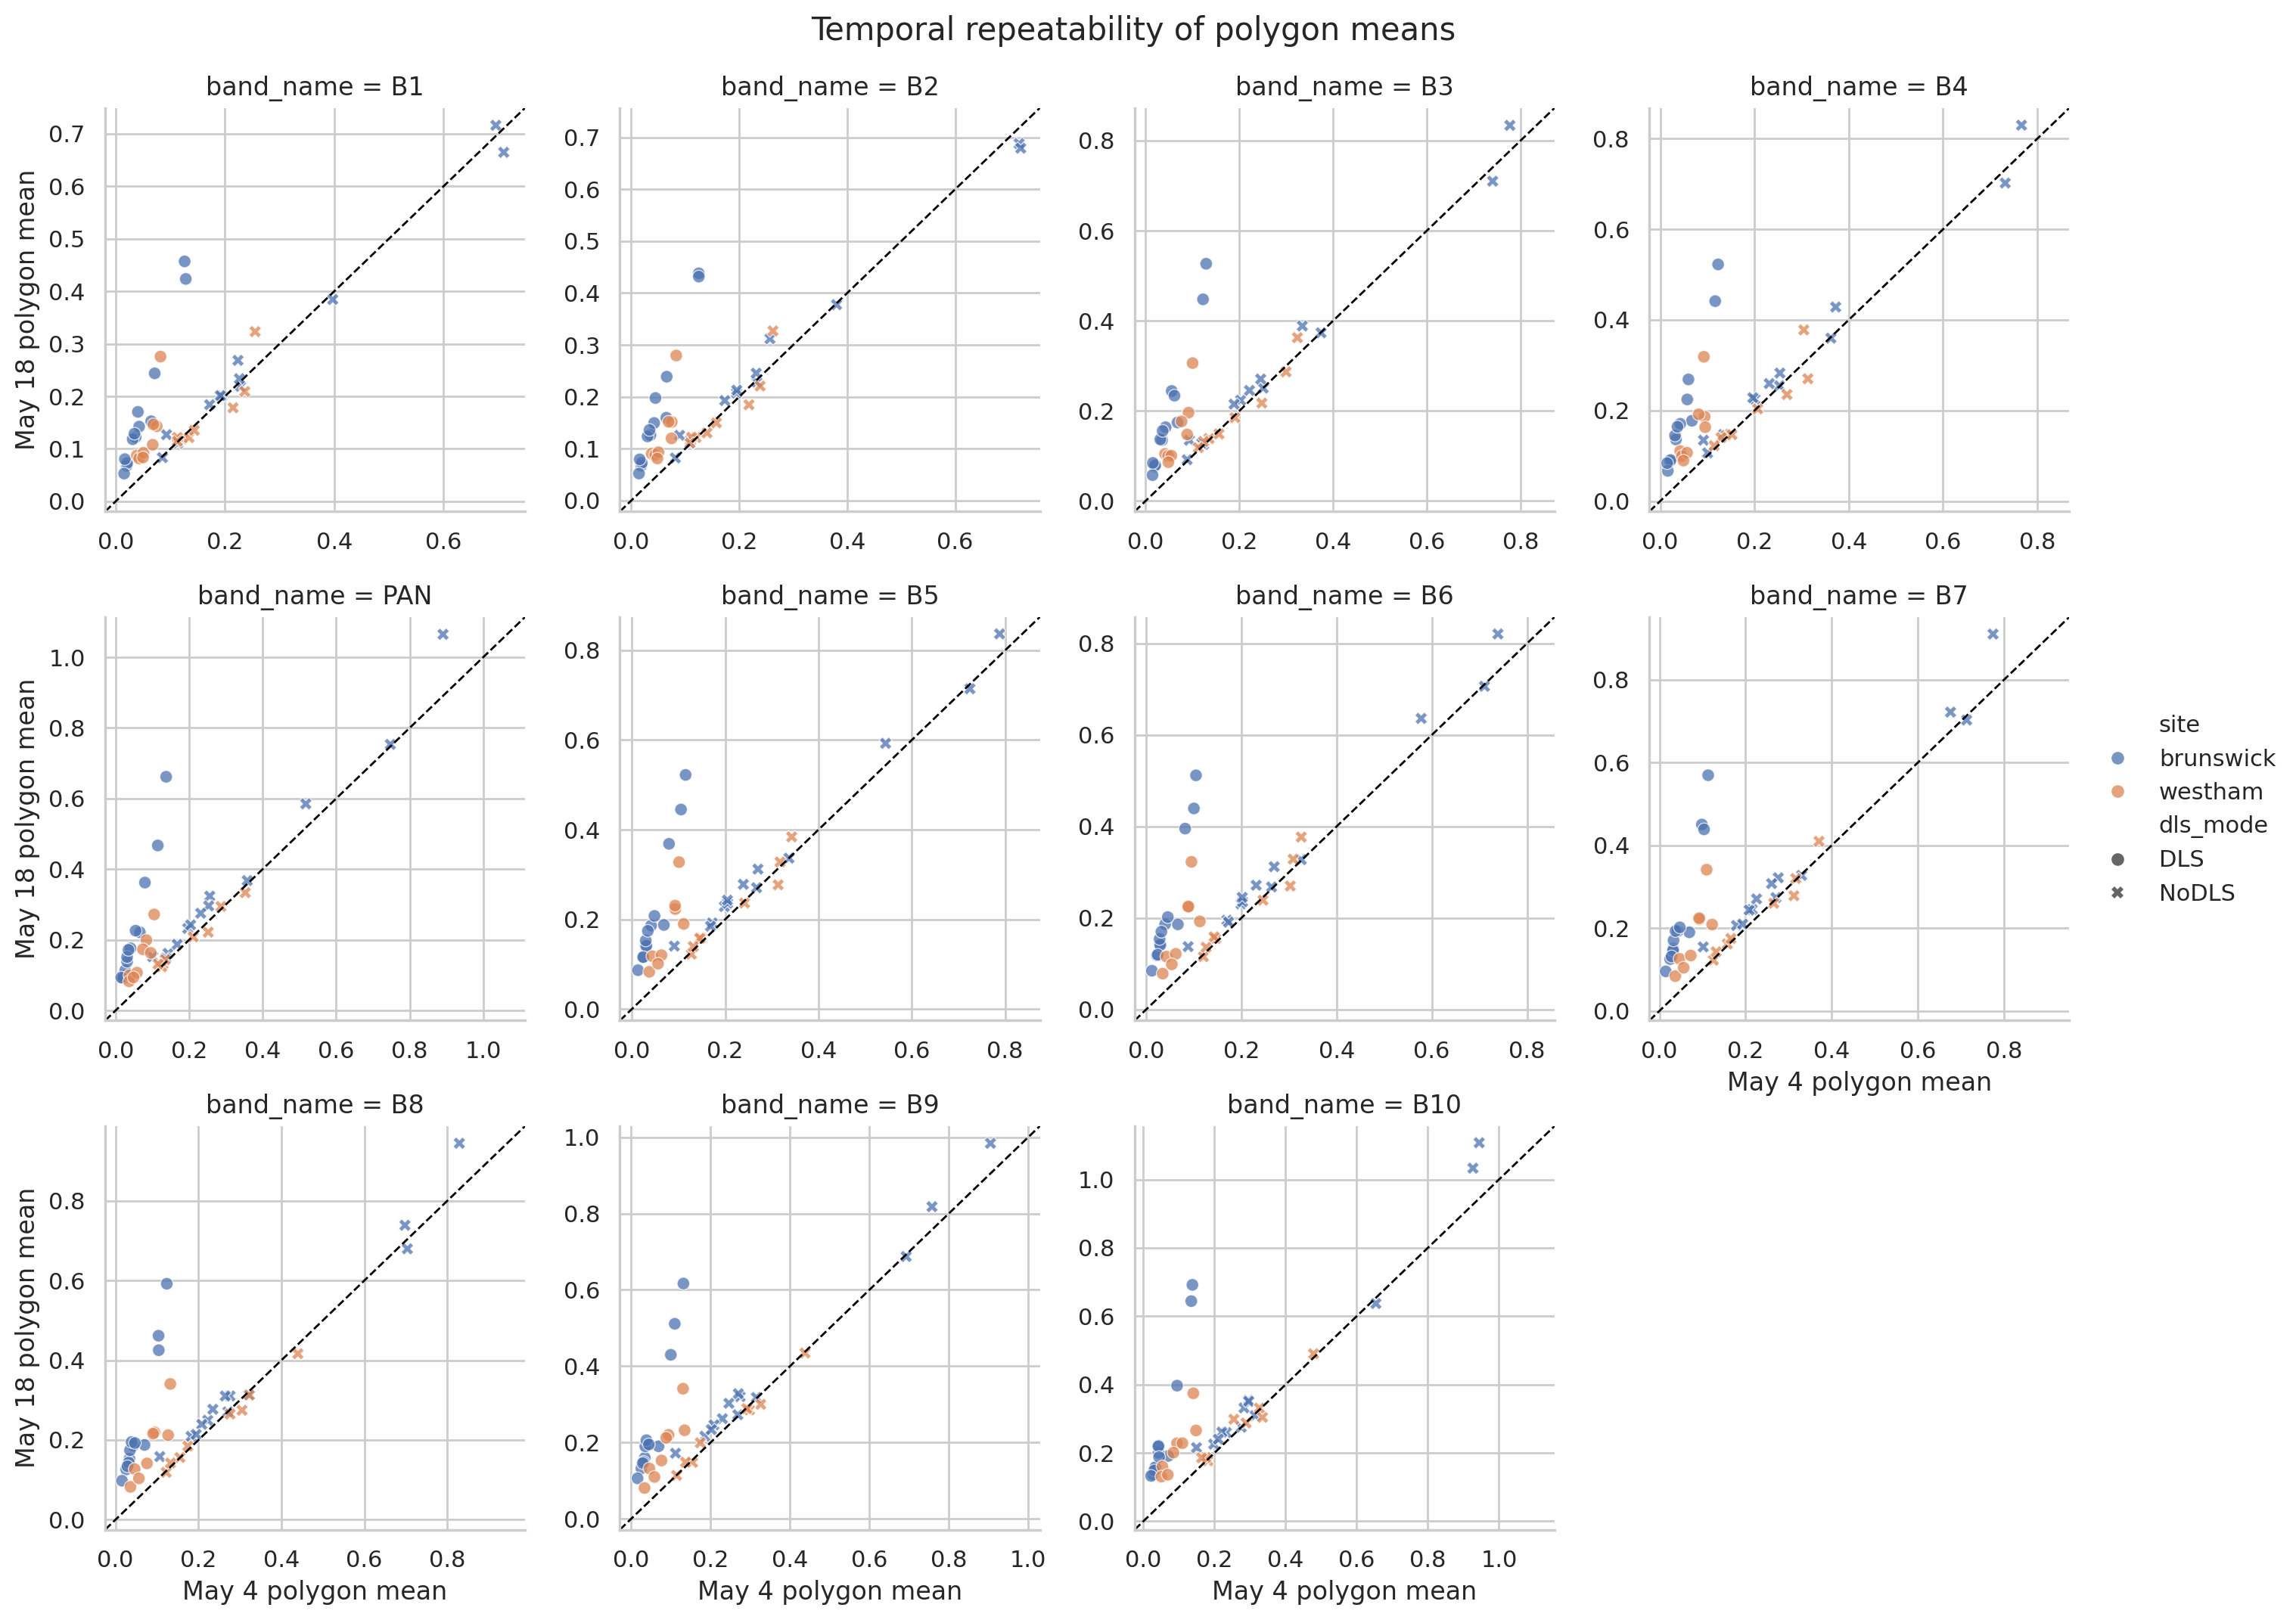

In [15]:
temporal_pairs = (
    polygon_band_summary
    .pivot_table(
        index=[
            "site",
            "dls_mode",
            "feature_id",
            "band_name",
            "source_band",
            "is_pan",
        ],
        columns="flight_date",
        values="mean",
        aggfunc="first",
    )
    .reset_index()
    .merge(
        BAND_METADATA[
            ["band_name", "source_band", "wavelength_nm"]
        ],
        on=["band_name", "source_band"],
        how="left",
        validate="many_to_one",
    )
)
temporal_pairs.columns.name = None

temporal_pairs["difference_May18_minus_May04"] = (
    temporal_pairs["2026-05-18"]
    - temporal_pairs["2026-05-04"]
)
temporal_pairs["ratio_May18_to_May04"] = np.where(
    temporal_pairs["2026-05-04"].abs() > 0,
    temporal_pairs["2026-05-18"]
    / temporal_pairs["2026-05-04"],
    np.nan,
)

display(temporal_pairs.head())

if SAVE_OUTPUTS:
    temporal_pairs.to_parquet(
        OUTPUT_DIR / "paired_May04_May18_polygon_means.parquet",
        index=False,
    )

temporal_plot = temporal_pairs.dropna(
    subset=["2026-05-04", "2026-05-18"]
).copy()
temporal_plot["band_name"] = pd.Categorical(
    temporal_plot["band_name"],
    categories=SOURCE_BAND_NAMES,
    ordered=True,
)

g = sns.relplot(
    data=temporal_plot,
    x="2026-05-04",
    y="2026-05-18",
    hue="site",
    style="dls_mode",
    col="band_name",
    col_wrap=4,
    height=3.5,
    facet_kws={"sharex": False, "sharey": False},
    alpha=0.75,
)

for ax in g.axes.flat:
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    low = min(xlim[0], ylim[0])
    high = max(xlim[1], ylim[1])
    ax.plot(
        [low, high], [low, high],
        "--", color="black", linewidth=1,
    )
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)

g.set_axis_labels(
    "May 4 polygon mean",
    "May 18 polygon mean",
)
g.fig.suptitle(
    "Temporal repeatability of polygon means",
    y=1.02,
    fontsize=15,
)
plt.show()

## 16. Fit temporal radiometric correction factors with uncertainty

This section fits linear transformations between the May 4 and May 18
acquisitions using paired polygon means for the same site, DLS mode,
feature, and band:

\[
y_{\mathrm{target}} =
\mathrm{gain}\,x_{\mathrm{source}} + \mathrm{offset}
\]

It calculates:

1. Separate fits for all 11 source bands, including PAN.
2. One pooled fit across the 10 narrow spectral bands, excluding PAN.
3. May 4 → May 18 and May 18 → May 4 fits independently.
4. Separate results for Westham/Brunswick and DLS/NoDLS.
5. 95% feature-cluster bootstrap confidence intervals for gain and offset.

Features, rather than individual band observations, are resampled in the
bootstrap. This prevents the pooled 10-band fit from treating the ten
correlated band observations from a feature as ten independent features.

In [16]:
from hashlib import sha256
from sklearn.linear_model import LinearRegression

DATE_MAY04 = "2026-05-04"
DATE_MAY18 = "2026-05-18"

TEMPORAL_FIT_DIRECTIONS = [
    (DATE_MAY04, DATE_MAY18),
    (DATE_MAY18, DATE_MAY04),
]

FIT_TEMPORAL_CORRECTIONS_BY_SITE = True
MIN_TEMPORAL_FIT_FEATURES = 3

BOOTSTRAP_REPLICATES = 2_000
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95
BOOTSTRAP_BASE_SEED = 42

### 16.1 Pair matching feature-band observations between dates

In [17]:
temporal_pair_index = [
    "site",
    "dls_mode",
    "feature_id",
    "band_name",
    "source_band",
    "is_pan",
]

# wavelength_nm is not part of the pivot index because PAN has a missing
# wavelength and would otherwise be dropped.
temporal_paired = (
    polygon_band_summary
    .pivot_table(
        index=temporal_pair_index,
        columns="flight_date",
        values="mean",
        aggfunc="first",
    )
    .reset_index()
)
temporal_paired.columns.name = None

missing_dates = {
    DATE_MAY04,
    DATE_MAY18,
}.difference(temporal_paired.columns)

if missing_dates:
    raise KeyError(
        "The temporal pairing table is missing date columns: "
        f"{sorted(missing_dates)}"
    )

temporal_paired = temporal_paired.merge(
    BAND_METADATA[
        [
            "band_name",
            "source_band",
            "wavelength_nm",
        ]
    ],
    on=["band_name", "source_band"],
    how="left",
    validate="many_to_one",
)

temporal_paired["has_both_dates"] = (
    temporal_paired[DATE_MAY04].notna()
    & temporal_paired[DATE_MAY18].notna()
)

temporal_pair_qc = (
    temporal_paired
    .groupby(
        ["site", "dls_mode", "band_name"],
        observed=True,
        dropna=False,
    )
    .agg(
        available_may04=(DATE_MAY04, "count"),
        available_may18=(DATE_MAY18, "count"),
        paired_features=("has_both_dates", "sum"),
    )
    .reset_index()
)

display(temporal_pair_qc)

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    temporal_paired.to_parquet(
        OUTPUT_DIR / "temporal_paired_polygon_band_means.parquet",
        index=False,
    )
    temporal_pair_qc.to_csv(
        OUTPUT_DIR / "temporal_pairing_qc.csv",
        index=False,
    )

,site,dls_mode,band_name,available_may04,available_may18,paired_features
0,brunswick,DLS,B1,13,13,13
1,brunswick,DLS,B10,13,13,13
2,brunswick,DLS,B2,13,13,13
3,brunswick,DLS,B3,13,13,13
4,brunswick,DLS,B4,13,13,13
5,brunswick,DLS,B5,13,13,13
6,brunswick,DLS,B6,13,13,13
7,brunswick,DLS,B7,13,13,13
8,brunswick,DLS,B8,13,13,13
9,brunswick,DLS,B9,13,13,13


### 16.2 Linear fit and feature-cluster bootstrap uncertainty

In [18]:
def stable_random_seed(*values, base_seed=BOOTSTRAP_BASE_SEED):
    text = "|".join(str(value) for value in values)
    digest = sha256(text.encode("utf-8")).digest()
    return (
        int.from_bytes(digest[:8], "little") + base_seed
    ) % (2 ** 32)


def fit_simple_linear_model(x, y):
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    predicted = model.predict(x.reshape(-1, 1))

    return {
        "gain": float(model.coef_[0]),
        "offset": float(model.intercept_),
        "predicted": predicted,
    }


def fit_temporal_linear_correction(
    data,
    *,
    source_date,
    target_date,
    cluster_column="feature_id",
    minimum_features=MIN_TEMPORAL_FIT_FEATURES,
    bootstrap_replicates=BOOTSTRAP_REPLICATES,
    confidence_level=BOOTSTRAP_CONFIDENCE_LEVEL,
    random_seed=BOOTSTRAP_BASE_SEED,
):
    valid = (
        data[
            [
                cluster_column,
                source_date,
                target_date,
            ]
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    n_observations = len(valid)
    cluster_values = valid[cluster_column].unique()
    n_features = len(cluster_values)

    source_mean = (
        valid[source_date].mean()
        if n_observations else np.nan
    )
    target_mean = (
        valid[target_date].mean()
        if n_observations else np.nan
    )

    invalid_fit = (
        n_features < minimum_features
        or valid[source_date].nunique() < 2
    )

    if invalid_fit:
        return {
            "n_observations": n_observations,
            "n_features": n_features,
            "gain": np.nan,
            "offset": np.nan,
            "gain_bootstrap_se": np.nan,
            "gain_ci_low": np.nan,
            "gain_ci_high": np.nan,
            "offset_bootstrap_se": np.nan,
            "offset_ci_low": np.nan,
            "offset_ci_high": np.nan,
            "bootstrap_replicates_requested": bootstrap_replicates,
            "bootstrap_replicates_successful": 0,
            "confidence_level": confidence_level,
            "r2": np.nan,
            "rmse": np.nan,
            "mae": np.nan,
            "bias_after_correction": np.nan,
            "source_mean": source_mean,
            "target_mean": target_mean,
            "fit_status": (
                "insufficient_features_or_source_variation"
            ),
        }

    x = valid[source_date].to_numpy(dtype=float)
    y = valid[target_date].to_numpy(dtype=float)

    point_fit = fit_simple_linear_model(x, y)
    predicted = point_fit["predicted"]
    residual = predicted - y

    rng = np.random.default_rng(random_seed)
    bootstrap_gain = []
    bootstrap_offset = []

    # Resample complete features as clusters. For the pooled 10-band fit,
    # every sampled feature retains all ten associated band observations.
    for _ in range(bootstrap_replicates):
        sampled_features = rng.choice(
            cluster_values,
            size=n_features,
            replace=True,
        )

        bootstrap_sample = pd.concat(
            [
                valid.loc[
                    valid[cluster_column].eq(feature_id)
                ]
                for feature_id in sampled_features
            ],
            ignore_index=True,
        )

        if (
            len(bootstrap_sample) < 2
            or bootstrap_sample[source_date].nunique() < 2
        ):
            continue

        bootstrap_x = bootstrap_sample[
            source_date
        ].to_numpy(dtype=float)
        bootstrap_y = bootstrap_sample[
            target_date
        ].to_numpy(dtype=float)

        bootstrap_fit = fit_simple_linear_model(
            bootstrap_x,
            bootstrap_y,
        )
        bootstrap_gain.append(bootstrap_fit["gain"])
        bootstrap_offset.append(bootstrap_fit["offset"])

    bootstrap_gain = np.asarray(
        bootstrap_gain,
        dtype=float,
    )
    bootstrap_offset = np.asarray(
        bootstrap_offset,
        dtype=float,
    )

    alpha = 1 - confidence_level
    lower_quantile = alpha / 2
    upper_quantile = 1 - alpha / 2

    if len(bootstrap_gain):
        gain_ci_low, gain_ci_high = np.quantile(
            bootstrap_gain,
            [lower_quantile, upper_quantile],
        )
        offset_ci_low, offset_ci_high = np.quantile(
            bootstrap_offset,
            [lower_quantile, upper_quantile],
        )
        gain_bootstrap_se = bootstrap_gain.std(ddof=1)
        offset_bootstrap_se = bootstrap_offset.std(ddof=1)
    else:
        gain_ci_low = gain_ci_high = np.nan
        offset_ci_low = offset_ci_high = np.nan
        gain_bootstrap_se = np.nan
        offset_bootstrap_se = np.nan

    return {
        "n_observations": n_observations,
        "n_features": n_features,
        "gain": point_fit["gain"],
        "offset": point_fit["offset"],
        "gain_bootstrap_se": float(gain_bootstrap_se),
        "gain_ci_low": float(gain_ci_low),
        "gain_ci_high": float(gain_ci_high),
        "offset_bootstrap_se": float(offset_bootstrap_se),
        "offset_ci_low": float(offset_ci_low),
        "offset_ci_high": float(offset_ci_high),
        "bootstrap_replicates_requested": bootstrap_replicates,
        "bootstrap_replicates_successful": len(
            bootstrap_gain
        ),
        "confidence_level": confidence_level,
        "r2": float(r2_score(y, predicted)),
        "rmse": float(
            np.sqrt(np.mean((predicted - y) ** 2))
        ),
        "mae": float(np.mean(np.abs(predicted - y))),
        "bias_after_correction": float(residual.mean()),
        "source_mean": float(source_mean),
        "target_mean": float(target_mean),
        "fit_status": "ok",
    }

### 16.3 Fit all individual bands, including PAN

In [19]:
temporal_fit_group_columns = ["dls_mode"]

if FIT_TEMPORAL_CORRECTIONS_BY_SITE:
    temporal_fit_group_columns.insert(0, "site")

per_band_group_columns = temporal_fit_group_columns + [
    "band_name",
    "source_band",
    "is_pan",
]

per_band_fit_records = []

for group_values, group in temporal_paired.groupby(
    per_band_group_columns,
    observed=True,
    dropna=False,
):
    if not isinstance(group_values, tuple):
        group_values = (group_values,)

    group_metadata = dict(
        zip(per_band_group_columns, group_values)
    )

    band_wavelength = BAND_METADATA.loc[
        BAND_METADATA["band_name"].eq(
            group_metadata["band_name"]
        ),
        "wavelength_nm",
    ]
    wavelength_nm = (
        band_wavelength.iloc[0]
        if len(band_wavelength)
        else np.nan
    )

    for source_date, target_date in TEMPORAL_FIT_DIRECTIONS:
        direction = f"{source_date}_to_{target_date}"
        fit = fit_temporal_linear_correction(
            group,
            source_date=source_date,
            target_date=target_date,
            random_seed=stable_random_seed(
                "individual_band",
                *group_values,
                direction,
            ),
        )

        per_band_fit_records.append({
            **group_metadata,
            "wavelength_nm": wavelength_nm,
            "fit_scope": "individual_band",
            "source_date": source_date,
            "target_date": target_date,
            "direction": direction,
            **fit,
        })

temporal_per_band_factors = (
    pd.DataFrame(per_band_fit_records)
    .sort_values(
        temporal_fit_group_columns
        + ["source_date", "source_band"]
    )
    .reset_index(drop=True)
)

display(temporal_per_band_factors)

,site,dls_mode,band_name,source_band,is_pan,wavelength_nm,fit_scope,source_date,target_date,direction,n_observations,n_features,gain,offset,gain_bootstrap_se,gain_ci_low,gain_ci_high,offset_bootstrap_se,offset_ci_low,offset_ci_high,bootstrap_replicates_requested,bootstrap_replicates_successful,confidence_level,r2,rmse,mae,bias_after_correction,source_mean,target_mean,fit_status
0,brunswick,DLS,B1,1,False,444.0,individual_band,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,13,13,3.322972,0.005612,0.306401,2.274112,3.609557,0.010994,-0.009312,0.037102,2000,2000,0.95,0.963673,0.023720,0.015288,-2.401925e-17,0.050019,0.171824,ok
1,brunswick,DLS,B2,2,False,475.0,individual_band,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,13,13,3.305021,0.013407,0.231928,2.545014,3.516654,0.008419,-0.000727,0.035505,2000,2000,0.95,0.964646,0.022935,0.014946,2.989062e-17,0.048830,0.174793,ok
2,brunswick,DLS,B3,3,False,531.0,individual_band,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,13,13,3.713462,0.006976,0.362899,2.514167,4.083003,0.012495,-0.009435,0.042563,2000,2000,0.95,0.955972,0.028881,0.018011,6.405133e-18,0.050228,0.193496,ok
3,brunswick,DLS,B4,4,False,560.0,individual_band,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,13,13,3.830207,0.009351,0.404382,2.512971,4.260796,0.013498,-0.009756,0.048054,2000,2000,0.95,0.949171,0.030189,0.018562,-1.814788e-17,0.049345,0.198352,ok
4,brunswick,DLS,PAN,5,True,NaN,individual_band,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,13,13,4.407117,-0.000657,0.432349,3.151834,4.839034,0.015934,-0.024350,0.038758,2000,2000,0.95,0.969075,0.028840,0.019524,-5.657867e-17,0.052073,0.228836,ok
5,brunswick,DLS,B5,6,False,650.0,individual_band,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,13,13,4.056863,0.017515,0.484356,2.304068,4.434932,0.015575,-0.000842,0.070854,2000,2000,0.95,0.934454,0.033668,0.018410,-2.028292e-17,0.049636,0.218883,ok
6,brunswick,DLS,B6,7,False,668.0,individual_band,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,13,13,4.268245,0.015838,0.512796,2.741783,4.771045,0.016430,-0.006425,0.056259,2000,2000,0.95,0.922590,0.036548,0.020697,2.241796e-17,0.047725,0.219541,ok
7,brunswick,DLS,B7,8,False,705.0,individual_band,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,13,13,4.337333,0.009573,0.549837,3.011303,4.946390,0.019914,-0.018471,0.052442,2000,2000,0.95,0.919643,0.040677,0.023849,2.775558e-17,0.051985,0.235049,ok
8,brunswick,DLS,B8,9,False,717.0,individual_band,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,13,13,4.233381,0.007445,0.565056,2.578853,4.737542,0.021304,-0.020495,0.058766,2000,2000,0.95,0.930143,0.038963,0.024133,2.562053e-17,0.053984,0.235981,ok
9,brunswick,DLS,B9,10,False,740.0,individual_band,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,13,13,4.295132,0.014169,0.477281,2.975588,4.603566,0.018353,-0.009139,0.057862,2000,2000,0.95,0.940884,0.037779,0.022598,-1.601283e-17,0.054444,0.248013,ok


### 16.4 Fit all 10 narrow spectral bands together, excluding PAN

In [20]:
ten_band_data = temporal_paired.loc[
    ~temporal_paired["is_pan"]
    & temporal_paired["band_name"].ne("PAN")
].copy()

all_ten_band_fit_records = []

for group_values, group in ten_band_data.groupby(
    temporal_fit_group_columns,
    observed=True,
    dropna=False,
):
    if not isinstance(group_values, tuple):
        group_values = (group_values,)

    group_metadata = dict(
        zip(temporal_fit_group_columns, group_values)
    )

    for source_date, target_date in TEMPORAL_FIT_DIRECTIONS:
        direction = f"{source_date}_to_{target_date}"
        fit = fit_temporal_linear_correction(
            group,
            source_date=source_date,
            target_date=target_date,
            random_seed=stable_random_seed(
                "all_10_spectral_bands_pooled",
                *group_values,
                direction,
            ),
        )

        all_ten_band_fit_records.append({
            **group_metadata,
            "band_name": "ALL_10_SPECTRAL_BANDS",
            "source_band": pd.NA,
            "is_pan": False,
            "wavelength_nm": np.nan,
            "fit_scope": (
                "all_10_spectral_bands_pooled"
            ),
            "source_date": source_date,
            "target_date": target_date,
            "direction": direction,
            **fit,
        })

temporal_all_ten_band_factors = (
    pd.DataFrame(all_ten_band_fit_records)
    .sort_values(
        temporal_fit_group_columns
        + ["source_date"]
    )
    .reset_index(drop=True)
)

display(temporal_all_ten_band_factors)

,site,dls_mode,band_name,source_band,is_pan,wavelength_nm,fit_scope,source_date,target_date,direction,n_observations,n_features,gain,offset,gain_bootstrap_se,gain_ci_low,gain_ci_high,offset_bootstrap_se,offset_ci_low,offset_ci_high,bootstrap_replicates_requested,bootstrap_replicates_successful,confidence_level,r2,rmse,mae,bias_after_correction,source_mean,target_mean,fit_status
0,brunswick,DLS,ALL_10_SPECTRAL_BANDS,<NA>,False,NaN,all_10_spectral_bands_pooled,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,130,13,4.013895,0.009926,0.412951,2.851932,4.474704,0.014294,-0.012485,0.043080,2000,2000,0.95,0.910380,0.043443,0.030421,1.110223e-17,0.051439,0.216397,ok
1,brunswick,DLS,ALL_10_SPECTRAL_BANDS,<NA>,False,NaN,all_10_spectral_bands_pooled,2026-05-18,2026-05-04,2026-05-18_to_2026-05-04,130,13,0.226807,0.002359,0.017417,0.205547,0.267867,0.003937,-0.005594,0.010557,2000,2000,0.95,0.910380,0.010327,0.007370,4.270089e-19,0.216397,0.051439,ok
2,brunswick,NoDLS,ALL_10_SPECTRAL_BANDS,<NA>,False,NaN,all_10_spectral_bands_pooled,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,130,13,1.024120,0.018438,0.054611,0.905441,1.096072,0.012916,-0.002978,0.045585,2000,2000,0.95,0.982308,0.030770,0.023366,-2.135044e-18,0.319225,0.345362,ok
3,brunswick,NoDLS,ALL_10_SPECTRAL_BANDS,<NA>,False,NaN,all_10_spectral_bands_pooled,2026-05-18,2026-05-04,2026-05-18_to_2026-05-04,130,13,0.959172,-0.012037,0.051048,0.902081,1.084173,0.013482,-0.044536,0.006989,2000,2000,0.95,0.982308,0.029779,0.022447,3.202566e-17,0.345362,0.319225,ok
4,westham,DLS,ALL_10_SPECTRAL_BANDS,<NA>,False,NaN,all_10_spectral_bands_pooled,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,80,8,2.320753,-0.004833,0.504989,1.497029,3.290444,0.028488,-0.064624,0.041775,2000,2000,0.95,0.727581,0.040427,0.030111,3.434752e-17,0.074376,0.167777,ok
5,westham,DLS,ALL_10_SPECTRAL_BANDS,<NA>,False,NaN,all_10_spectral_bands_pooled,2026-05-18,2026-05-04,2026-05-18_to_2026-05-04,80,8,0.313511,0.021777,0.082604,0.240089,0.544984,0.011562,-0.005758,0.038202,2000,2000,0.95,0.727581,0.014859,0.010397,-8.847090e-18,0.167777,0.074376,ok
6,westham,NoDLS,ALL_10_SPECTRAL_BANDS,<NA>,False,NaN,all_10_spectral_bands_pooled,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,80,8,0.989340,0.003757,0.064911,0.843837,1.074838,0.009512,-0.009611,0.026111,2000,2000,0.95,0.939044,0.023013,0.016336,-2.255141e-18,0.216333,0.217784,ok
7,westham,NoDLS,ALL_10_SPECTRAL_BANDS,<NA>,False,NaN,all_10_spectral_bands_pooled,2026-05-18,2026-05-04,2026-05-18_to_2026-05-04,80,8,0.949162,0.009620,0.072999,0.878126,1.122231,0.013127,-0.018276,0.031095,2000,2000,0.95,0.939044,0.022541,0.016872,3.989864e-18,0.217784,0.216333,ok


### 16.5 Save correction coefficients and uncertainty

In [21]:
temporal_correction_factors = pd.concat(
    [
        temporal_per_band_factors,
        temporal_all_ten_band_factors,
    ],
    ignore_index=True,
    sort=False,
)

coefficient_columns = [
    "site",
    "dls_mode",
    "fit_scope",
    "band_name",
    "source_band",
    "wavelength_nm",
    "is_pan",
    "source_date",
    "target_date",
    "direction",
    "gain",
    "offset",
    "gain_bootstrap_se",
    "gain_ci_low",
    "gain_ci_high",
    "offset_bootstrap_se",
    "offset_ci_low",
    "offset_ci_high",
    "confidence_level",
    "n_features",
    "n_observations",
    "bootstrap_replicates_requested",
    "bootstrap_replicates_successful",
    "r2",
    "rmse",
    "mae",
    "bias_after_correction",
    "source_mean",
    "target_mean",
    "fit_status",
]

temporal_correction_factors = (
    temporal_correction_factors[
        [
            column
            for column in coefficient_columns
            if column in temporal_correction_factors.columns
        ]
    ]
    .sort_values(
        [
            "direction",
            "site",
            "dls_mode",
            "fit_scope",
            "source_band",
        ],
        na_position="last",
    )
    .reset_index(drop=True)
)

# This concise table is intended for directly applying the correction
# coefficients in the next processing step.
temporal_correction_coefficients = (
    temporal_correction_factors[
        [
            "site",
            "dls_mode",
            "fit_scope",
            "band_name",
            "source_band",
            "is_pan",
            "source_date",
            "target_date",
            "direction",
            "gain",
            "offset",
            "gain_ci_low",
            "gain_ci_high",
            "offset_ci_low",
            "offset_ci_high",
            "confidence_level",
            "n_features",
            "fit_status",
        ]
    ]
    .copy()
)

display(temporal_correction_coefficients)

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    full_csv_path = (
        OUTPUT_DIR
        / "temporal_correction_factors_with_uncertainty.csv"
    )
    full_parquet_path = (
        OUTPUT_DIR
        / "temporal_correction_factors_with_uncertainty.parquet"
    )
    coefficient_csv_path = (
        OUTPUT_DIR
        / "temporal_radiometric_correction_coefficients.csv"
    )
    coefficient_parquet_path = (
        OUTPUT_DIR
        / "temporal_radiometric_correction_coefficients.parquet"
    )
    coefficient_json_path = (
        OUTPUT_DIR
        / "temporal_radiometric_correction_coefficients.json"
    )

    temporal_correction_factors.to_csv(
        full_csv_path,
        index=False,
    )
    temporal_correction_factors.to_parquet(
        full_parquet_path,
        index=False,
    )
    temporal_correction_coefficients.to_csv(
        coefficient_csv_path,
        index=False,
    )
    temporal_correction_coefficients.to_parquet(
        coefficient_parquet_path,
        index=False,
    )

    json_records = (
        temporal_correction_coefficients
        .astype(object)
        .where(
            pd.notna(temporal_correction_coefficients),
            None,
        )
        .to_dict(orient="records")
    )

    with coefficient_json_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            json_records,
            file,
            indent=2,
        )

    print("Saved full fit table:", full_csv_path)
    print("Saved coefficient CSV:", coefficient_csv_path)
    print(
        "Saved coefficient Parquet:",
        coefficient_parquet_path,
    )
    print("Saved coefficient JSON:", coefficient_json_path)

,site,dls_mode,fit_scope,band_name,source_band,is_pan,source_date,target_date,direction,gain,offset,gain_ci_low,gain_ci_high,offset_ci_low,offset_ci_high,confidence_level,n_features,fit_status
0,brunswick,DLS,all_10_spectral_bands_pooled,ALL_10_SPECTRAL_BANDS,<NA>,False,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,4.013895,0.009926,2.851932,4.474704,-0.012485,0.043080,0.95,13,ok
1,brunswick,DLS,individual_band,B1,1,False,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,3.322972,0.005612,2.274112,3.609557,-0.009312,0.037102,0.95,13,ok
2,brunswick,DLS,individual_band,B2,2,False,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,3.305021,0.013407,2.545014,3.516654,-0.000727,0.035505,0.95,13,ok
3,brunswick,DLS,individual_band,B3,3,False,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,3.713462,0.006976,2.514167,4.083003,-0.009435,0.042563,0.95,13,ok
4,brunswick,DLS,individual_band,B4,4,False,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,3.830207,0.009351,2.512971,4.260796,-0.009756,0.048054,0.95,13,ok
5,brunswick,DLS,individual_band,PAN,5,True,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,4.407117,-0.000657,3.151834,4.839034,-0.024350,0.038758,0.95,13,ok
6,brunswick,DLS,individual_band,B5,6,False,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,4.056863,0.017515,2.304068,4.434932,-0.000842,0.070854,0.95,13,ok
7,brunswick,DLS,individual_band,B6,7,False,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,4.268245,0.015838,2.741783,4.771045,-0.006425,0.056259,0.95,13,ok
8,brunswick,DLS,individual_band,B7,8,False,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,4.337333,0.009573,3.011303,4.946390,-0.018471,0.052442,0.95,13,ok
9,brunswick,DLS,individual_band,B8,9,False,2026-05-04,2026-05-18,2026-05-04_to_2026-05-18,4.233381,0.007445,2.578853,4.737542,-0.020495,0.058766,0.95,13,ok


Saved full fit table: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/polygon_pixel_spectra/temporal_correction_factors_with_uncertainty.csv
Saved coefficient CSV: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/polygon_pixel_spectra/temporal_radiometric_correction_coefficients.csv
Saved coefficient Parquet: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/polygon_pixel_spectra/temporal_radiometric_correction_coefficients.parquet
Saved coefficient JSON: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/polygon_pixel_spectra/temporal_radiometric_correction_coefficients.json


### 16.6 Gain versus offset with 95% bootstrap confidence intervals

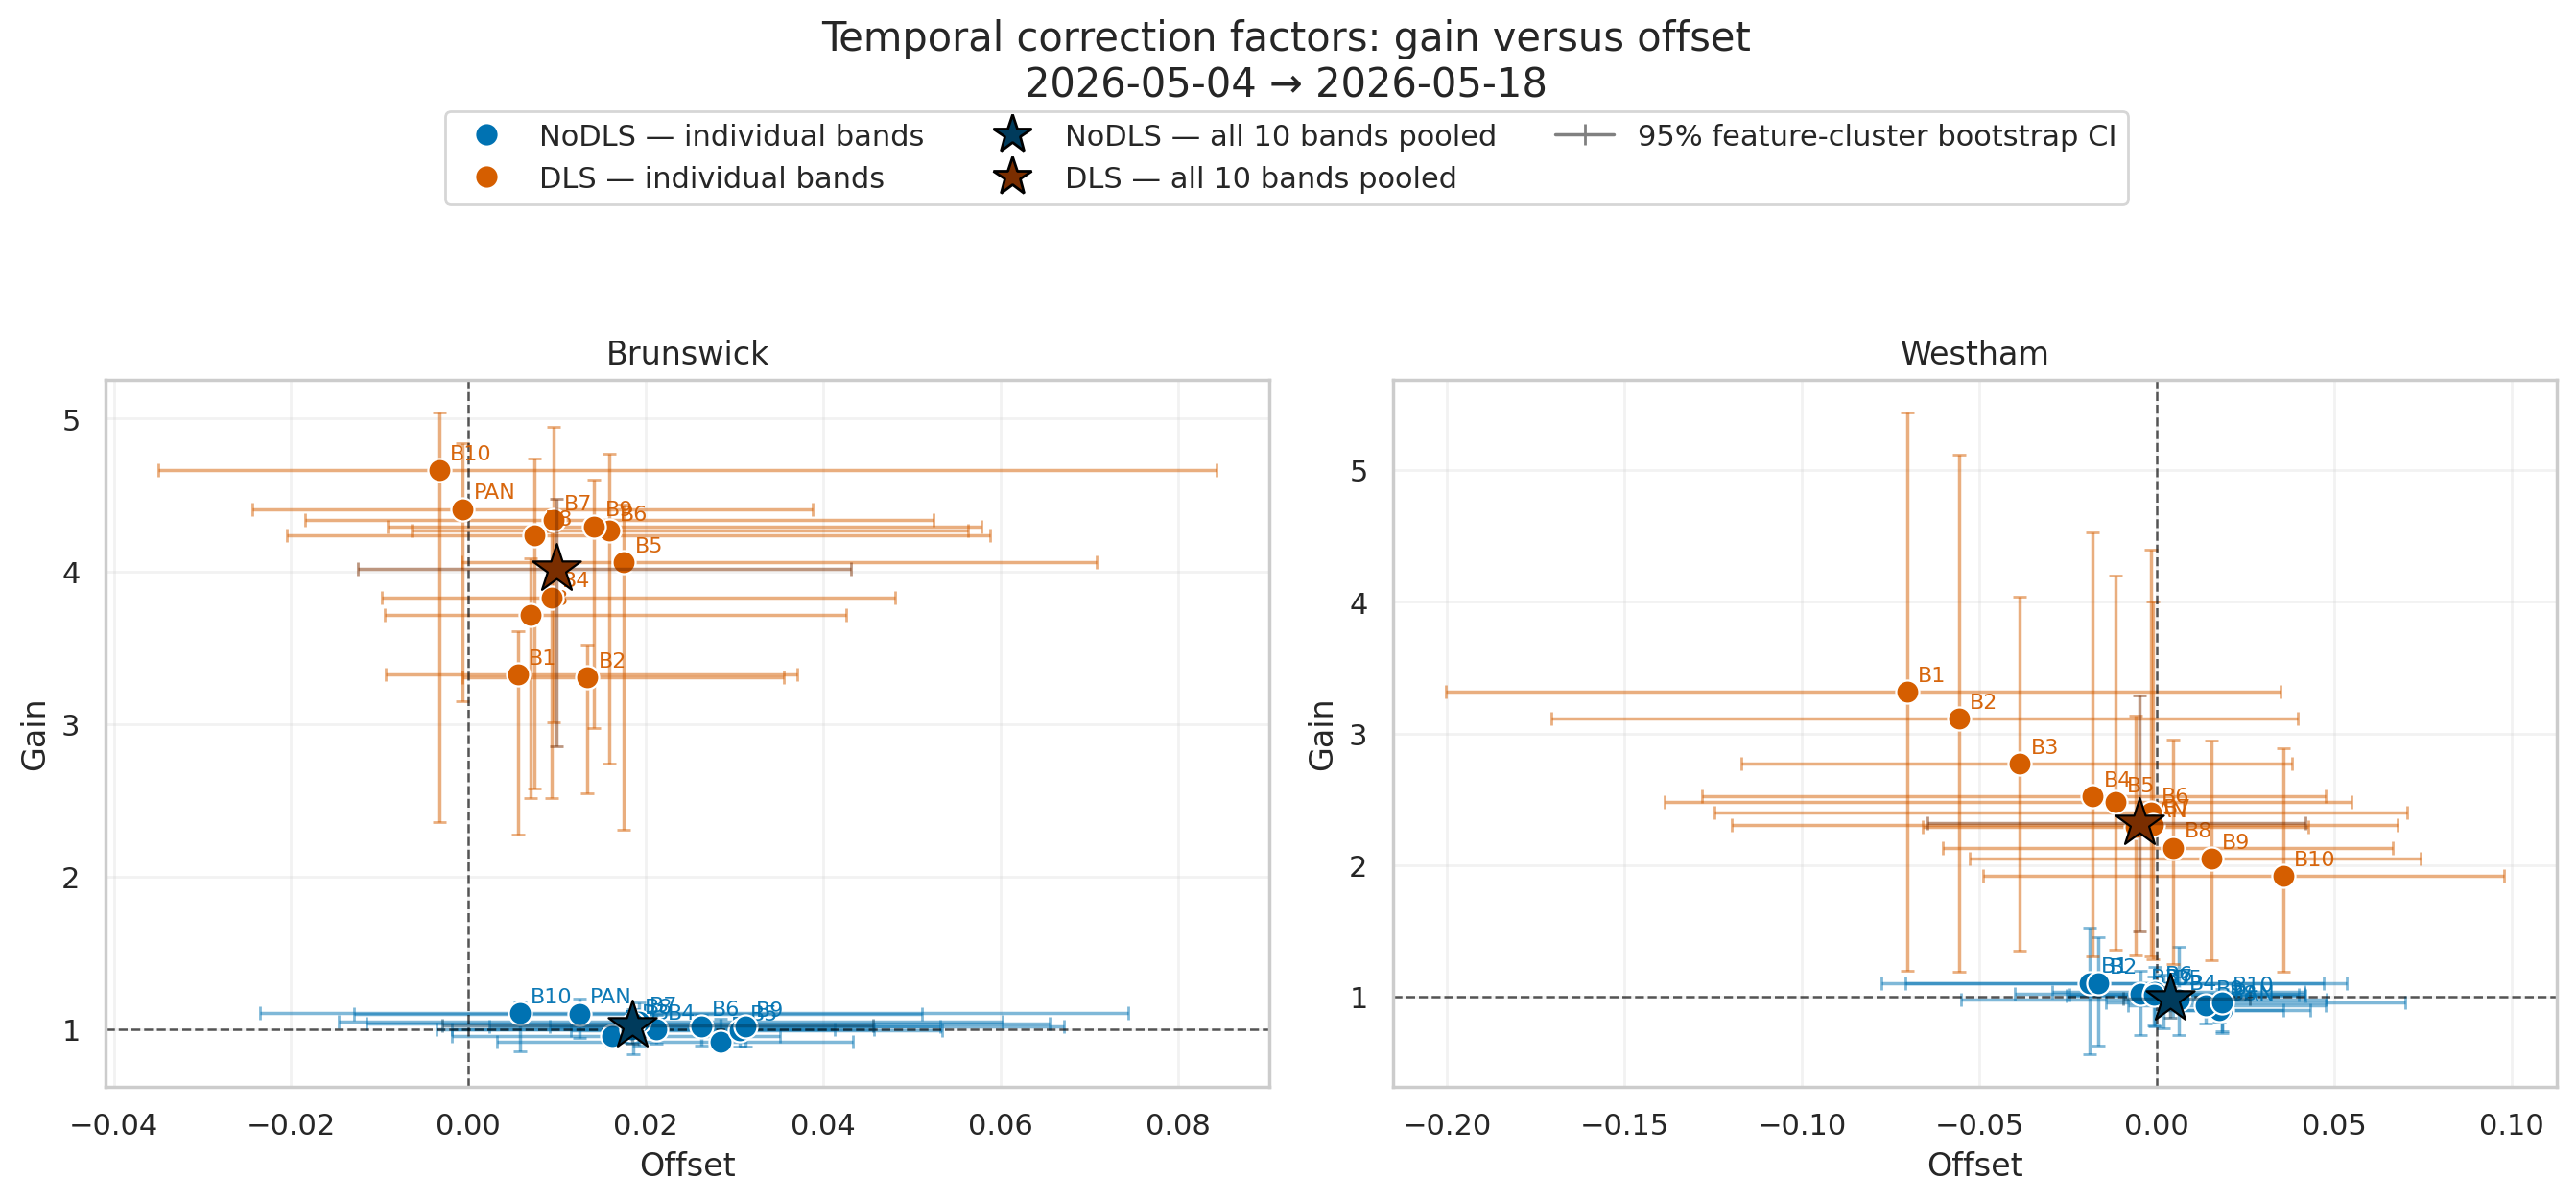

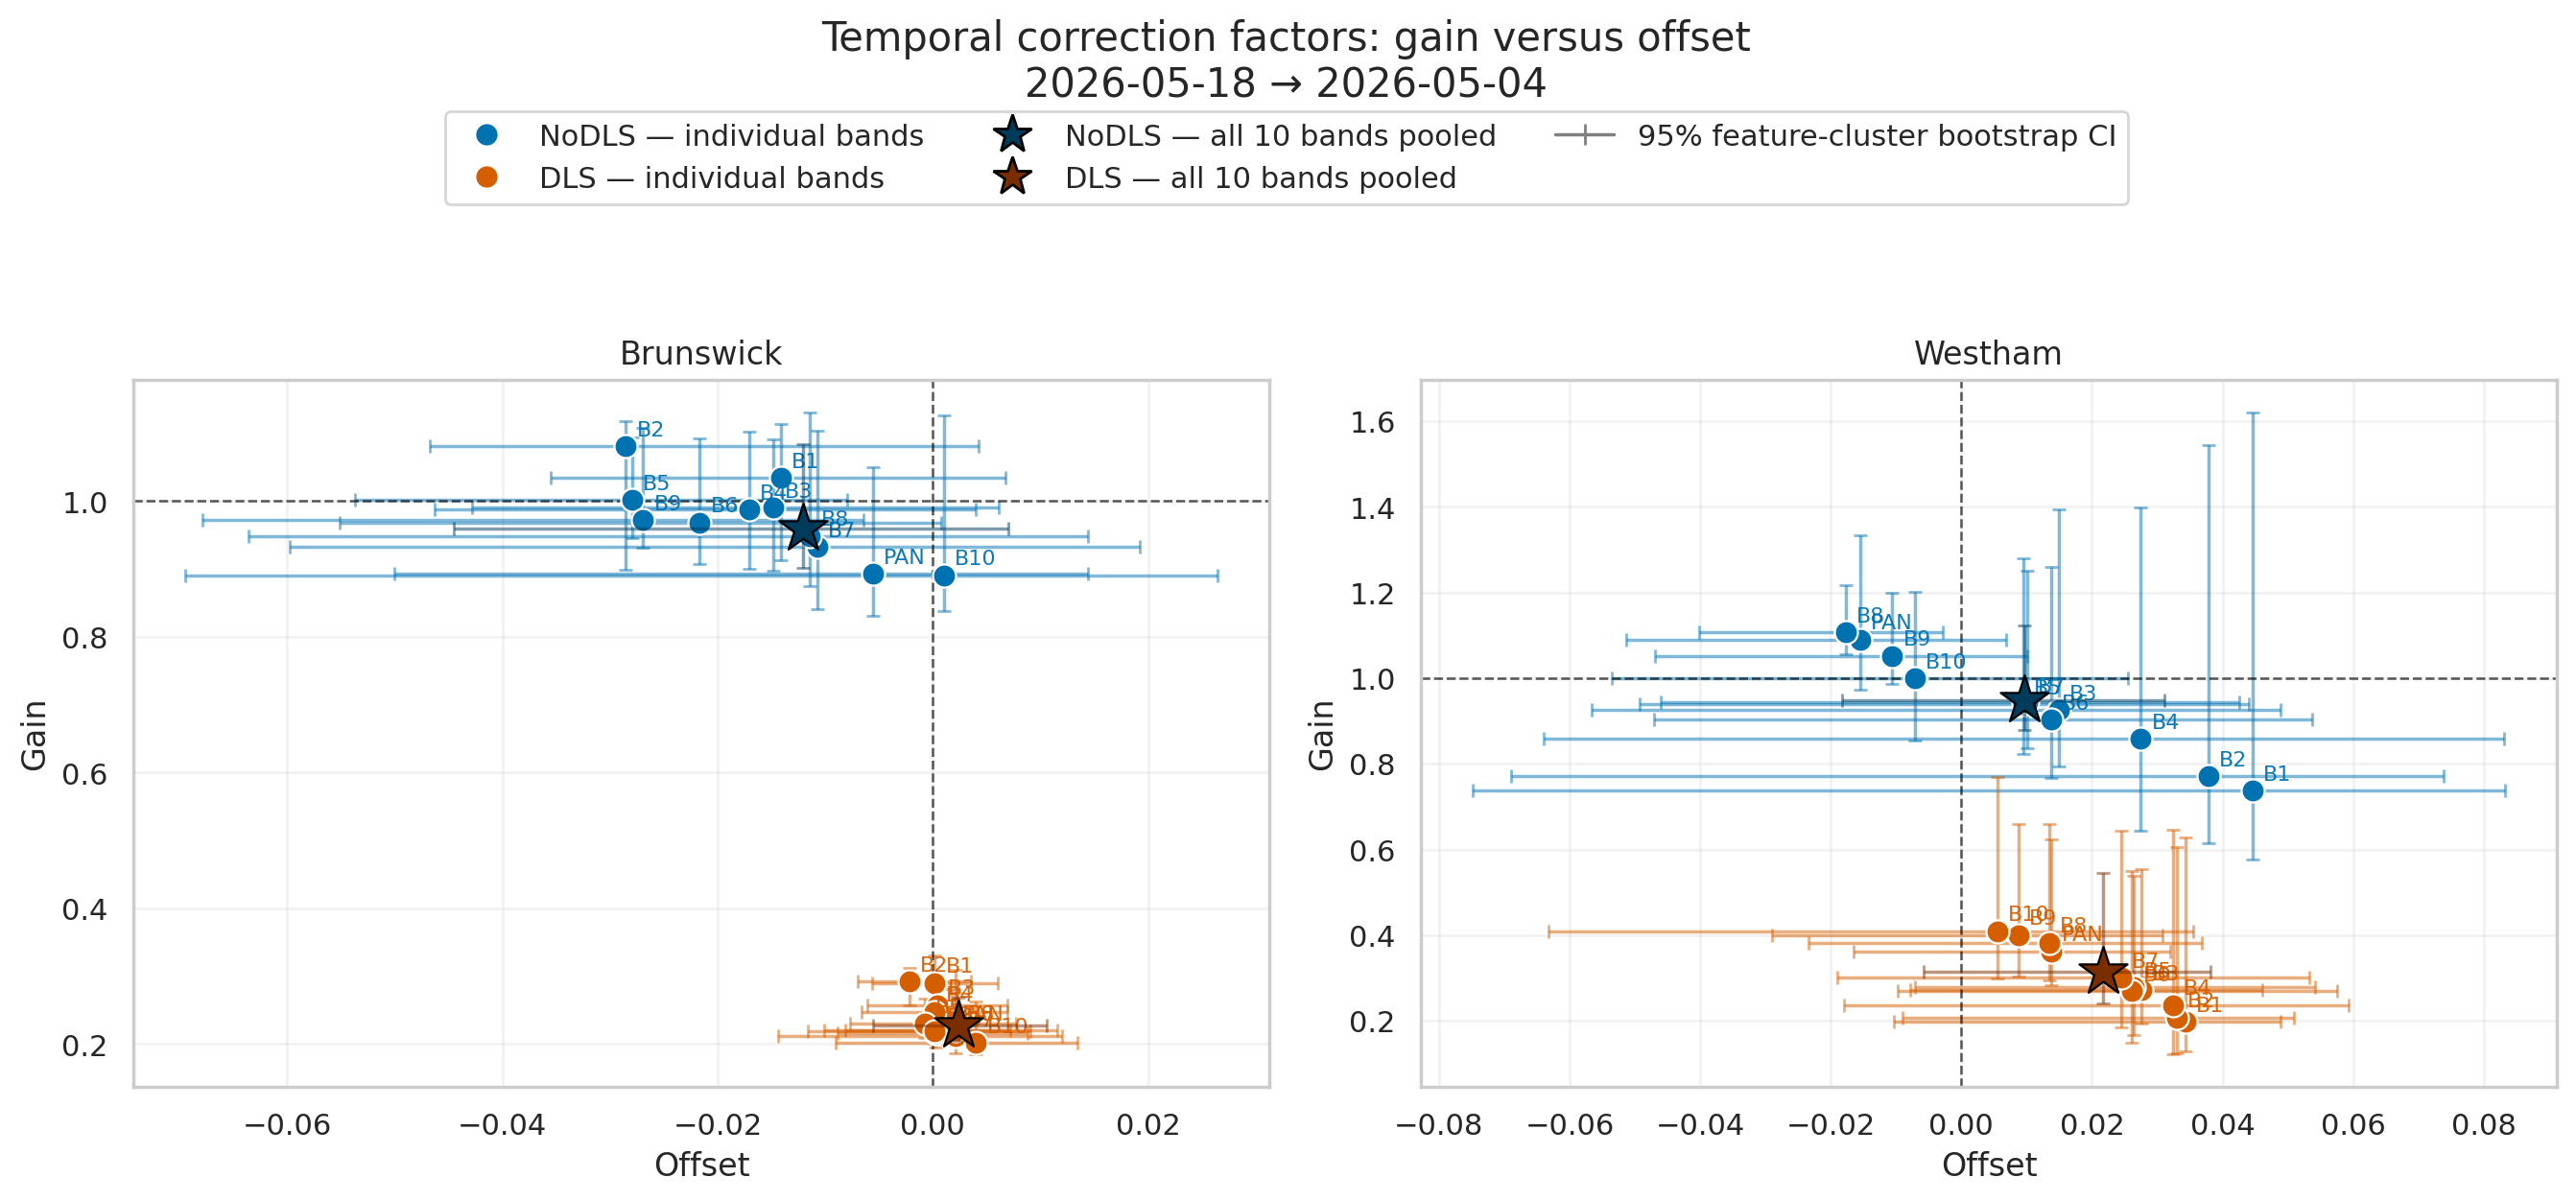

In [22]:
from matplotlib.lines import Line2D

INDIVIDUAL_COLORS = {
    "NoDLS": "#0072B2",
    "DLS": "#D55E00",
}

POOLED_COLORS = {
    "NoDLS": "#003B5C",
    "DLS": "#7A2E00",
}

DIRECTION_ORDER = [
    "2026-05-04_to_2026-05-18",
    "2026-05-18_to_2026-05-04",
]

gain_offset_plot_data = (
    temporal_correction_factors.loc[
        temporal_correction_factors["fit_status"].eq("ok")
        & temporal_correction_factors["fit_scope"].isin(
            [
                "individual_band",
                "all_10_spectral_bands_pooled",
            ]
        )
    ]
    .copy()
)

if "site" not in gain_offset_plot_data.columns:
    raise KeyError(
        "The correction-factor table has no 'site' column. "
        "Set FIT_TEMPORAL_CORRECTIONS_BY_SITE = True."
    )

sites = sorted(
    gain_offset_plot_data["site"].dropna().unique()
)


def plot_coefficient_with_uncertainty(
    ax,
    row,
    *,
    color,
    marker,
    marker_size,
    zorder,
):
    gain_lower_error = max(
        0,
        row["gain"] - row["gain_ci_low"],
    )
    gain_upper_error = max(
        0,
        row["gain_ci_high"] - row["gain"],
    )
    offset_lower_error = max(
        0,
        row["offset"] - row["offset_ci_low"],
    )
    offset_upper_error = max(
        0,
        row["offset_ci_high"] - row["offset"],
    )

    if np.isfinite(
        [
            gain_lower_error,
            gain_upper_error,
            offset_lower_error,
            offset_upper_error,
        ]
    ).all():
        ax.errorbar(
            row["offset"],
            row["gain"],
            xerr=np.array(
                [
                    [offset_lower_error],
                    [offset_upper_error],
                ]
            ),
            yerr=np.array(
                [
                    [gain_lower_error],
                    [gain_upper_error],
                ]
            ),
            fmt="none",
            ecolor=color,
            elinewidth=1.25,
            capsize=2.5,
            alpha=0.5,
            zorder=zorder - 1,
        )

    ax.scatter(
        row["offset"],
        row["gain"],
        color=color,
        marker=marker,
        s=marker_size,
        alpha=1,
        edgecolor="black" if marker == "*" else "white",
        linewidth=0.8,
        zorder=zorder,
    )


for direction in DIRECTION_ORDER:
    direction_data = gain_offset_plot_data.loc[
        gain_offset_plot_data["direction"].eq(direction)
    ]

    if direction_data.empty:
        print(
            f"No valid correction factors for {direction}"
        )
        continue

    # One panel per site. Axes are deliberately not shared.
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(sites),
        figsize=(6.8 * len(sites), 5.8),
        sharex=False,
        sharey=False,
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, site in zip(axes, sites):
        panel = direction_data.loc[
            direction_data["site"].eq(site)
        ]

        for dls_mode in ["NoDLS", "DLS"]:
            individual = panel.loc[
                panel["dls_mode"].eq(dls_mode)
                & panel["fit_scope"].eq(
                    "individual_band"
                )
            ]

            for _, point in individual.iterrows():
                plot_coefficient_with_uncertainty(
                    ax,
                    point,
                    color=INDIVIDUAL_COLORS[dls_mode],
                    marker="o",
                    marker_size=75,
                    zorder=3,
                )
                ax.annotate(
                    str(point["band_name"]),
                    (
                        point["offset"],
                        point["gain"],
                    ),
                    xytext=(4, 4),
                    textcoords="offset points",
                    fontsize=8,
                    color=INDIVIDUAL_COLORS[
                        dls_mode
                    ],
                    alpha=0.95,
                )

            pooled = panel.loc[
                panel["dls_mode"].eq(dls_mode)
                & panel["fit_scope"].eq(
                    "all_10_spectral_bands_pooled"
                )
            ]

            for _, point in pooled.iterrows():
                plot_coefficient_with_uncertainty(
                    ax,
                    point,
                    color=POOLED_COLORS[dls_mode],
                    marker="*",
                    marker_size=360,
                    zorder=6,
                )

        ax.axvline(
            0,
            color="black",
            linestyle="--",
            linewidth=0.9,
            alpha=0.65,
        )
        ax.axhline(
            1,
            color="black",
            linestyle="--",
            linewidth=0.9,
            alpha=0.65,
        )

        ax.set_title(site.title())
        ax.set_xlabel("Offset")
        ax.set_ylabel("Gain")
        ax.grid(True, alpha=0.25)

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=INDIVIDUAL_COLORS[
                "NoDLS"
            ],
            markeredgecolor="white",
            markersize=9,
            label="NoDLS — individual bands",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=INDIVIDUAL_COLORS[
                "DLS"
            ],
            markeredgecolor="white",
            markersize=9,
            label="DLS — individual bands",
        ),
        Line2D(
            [0],
            [0],
            marker="*",
            linestyle="none",
            markerfacecolor=POOLED_COLORS[
                "NoDLS"
            ],
            markeredgecolor="black",
            markersize=15,
            label=(
                "NoDLS — all 10 bands pooled"
            ),
        ),
        Line2D(
            [0],
            [0],
            marker="*",
            linestyle="none",
            markerfacecolor=POOLED_COLORS["DLS"],
            markeredgecolor="black",
            markersize=15,
            label=(
                "DLS — all 10 bands pooled"
            ),
        ),
        Line2D(
            [0],
            [0],
            color="gray",
            linewidth=1.25,
            marker="|",
            markersize=8,
            label=(
                f"{BOOTSTRAP_CONFIDENCE_LEVEL:.0%} "
                "feature-cluster bootstrap CI"
            ),
        ),
    ]

    source_date, target_date = direction.split(
        "_to_"
    )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=3,
        frameon=True,
    )
    fig.suptitle(
        "Temporal correction factors: "
        "gain versus offset\n"
        f"{source_date} → {target_date}",
        y=1.08,
        fontsize=15,
    )
    fig.tight_layout(
        rect=(0, 0, 1, 0.93)
    )
    plt.show()

### Applying the saved coefficients

Each coefficient row defines:

```python
corrected_value = gain * source_date_value + offset
```

Use `temporal_radiometric_correction_coefficients.csv`,
`.parquet`, or `.json` in the next processing step. The confidence interval
fields quantify uncertainty in the fitted gain and offset.

The pooled 10-band coefficients exclude PAN. PAN remains available as an
individual-band fit.

## 17. Output inventory

In [23]:
if SAVE_OUTPUTS:
    output_inventory = pd.DataFrame([
        {
            "name": path.name,
            "size_mb": path.stat().st_size / (1024 ** 2),
            "path": str(path),
        }
        for path in sorted(OUTPUT_DIR.glob("*"))
        if path.is_file()
    ])
    display(output_inventory)
else:
    print("SAVE_OUTPUTS is False; no files were written.")

,name,size_mb,path
0,20260504_brunswick_DLS_extraction_log.csv,0.000568,/home/coder/jchampion/Biofilm_LEG13553/confide...
1,20260504_brunswick_DLS_pixel_spectra.parquet,0.170235,/home/coder/jchampion/Biofilm_LEG13553/confide...
2,20260504_brunswick_DLS_polygon_band_summary.pa...,0.021544,/home/coder/jchampion/Biofilm_LEG13553/confide...
3,20260504_brunswick_NoDLS_extraction_log.csv,0.000592,/home/coder/jchampion/Biofilm_LEG13553/confide...
4,20260504_brunswick_NoDLS_pixel_spectra.parquet,0.169879,/home/coder/jchampion/Biofilm_LEG13553/confide...
5,20260504_brunswick_NoDLS_polygon_band_summary....,0.021537,/home/coder/jchampion/Biofilm_LEG13553/confide...
6,20260504_westham_DLS_extraction_log.csv,0.000357,/home/coder/jchampion/Biofilm_LEG13553/confide...
7,20260504_westham_DLS_pixel_spectra.parquet,0.051962,/home/coder/jchampion/Biofilm_LEG13553/confide...
8,20260504_westham_DLS_polygon_band_summary.parquet,0.017235,/home/coder/jchampion/Biofilm_LEG13553/confide...
9,20260504_westham_NoDLS_extraction_log.csv,0.000372,/home/coder/jchampion/Biofilm_LEG13553/confide...


## Interpretation checklist

1. Review pixel counts before interpreting a feature.
2. Use Section 9 to assess feature-level spatial variability and DLS/NoDLS
   spectral differences.
3. Use Section 12 to assess DLS versus NoDLS agreement.
4. Use Section 14 to inspect date-to-date repeatability.
5. Use Section 16 confidence intervals to assess whether apparent band-to-band
   differences are well constrained.
6. PAN is included in individual-band fits but excluded from the pooled
   10-band fit.
7. Wide intervals are expected where only a small number of paired features
   are available.